In [1]:

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import momlevel as ml

## for plotting
import cmocean 
import cartopy.crs as ccrs
import cartopy
import matplotlib.path as mpath
from matplotlib import gridspec

In [2]:
%matplotlib inline                           
%config InlineBackend.figure_format='retina' 
plt.rcParams['figure.figsize'] = 12,6  

In [3]:
# add font similar to arial used in the original code, but not available here 
import matplotlib as mpl
mpl.rcParams['font.family'] = 'DejaVu Sans'

### Load newly created mixed layer dataset with monthly data spanning Jan 2004 to Dec 2025

In [4]:
RG_MixedLayerProperties = xr.open_dataset('RG_MixedLayer_Properties_2004_to_Jan2004_Dec2025.nc')

In [5]:
RG_MixedLayerProperties.sel(time=slice('2020','2022'))

<xarray.Dataset>
Dimensions:              (longitude: 360, latitude: 145, time: 36, pressure: 58)
Coordinates:
  * longitude            (longitude) float32 20.5 21.5 22.5 ... 378.5 379.5
  * latitude             (latitude) float32 -64.5 -63.5 -62.5 ... 77.5 78.5 79.5
  * time                 (time) datetime64[ns] 2020-01-31 ... 2022-12-31
  * pressure             (pressure) float32 2.5 10.0 20.0 ... 1.9e+03 1.975e+03
Data variables:
    MLT_depth_ave        (latitude, longitude, time) float32 ...
    MLS_depth_ave        (latitude, longitude, time) float32 ...
    MLpotoRho_depth_ave  (latitude, longitude, time) float32 ...
    MLT                  (pressure, latitude, longitude, time) float32 ...
    MLS                  (pressure, latitude, longitude, time) float32 ...
    MLpotoRho            (pressure, latitude, longitude, time) float32 ...
    MLD                  (latitude, longitude, time) float32 ...

In [6]:
MLD = RG_MixedLayerProperties.MLD

In [7]:
MLD

<xarray.DataArray 'MLD' (latitude: 145, longitude: 360, time: 264)>
[13780800 values with dtype=float32]
Coordinates:
  * longitude  (longitude) float32 20.5 21.5 22.5 23.5 ... 377.5 378.5 379.5
  * latitude   (latitude) float32 -64.5 -63.5 -62.5 -61.5 ... 77.5 78.5 79.5
  * time       (time) datetime64[ns] 2004-01-31 2004-02-29 ... 2025-12-31

### Load in one of the other datasets that contains a land sea mask so I can mask out land values for mld

In [8]:
Temp = xr.open_dataset('Roemmich_Gilson_Temperature_Jan2004_Nov2025.nc')

In [9]:
Mask = Temp.MAPPING_MASK.isel(pressure=0).where(Temp.MAPPING_MASK.isel(pressure=0)==2000,0) / Temp.MAPPING_MASK.isel(pressure=0).where(Temp.MAPPING_MASK.isel(pressure=0)==2000,0) 
Mask = Mask.squeeze()

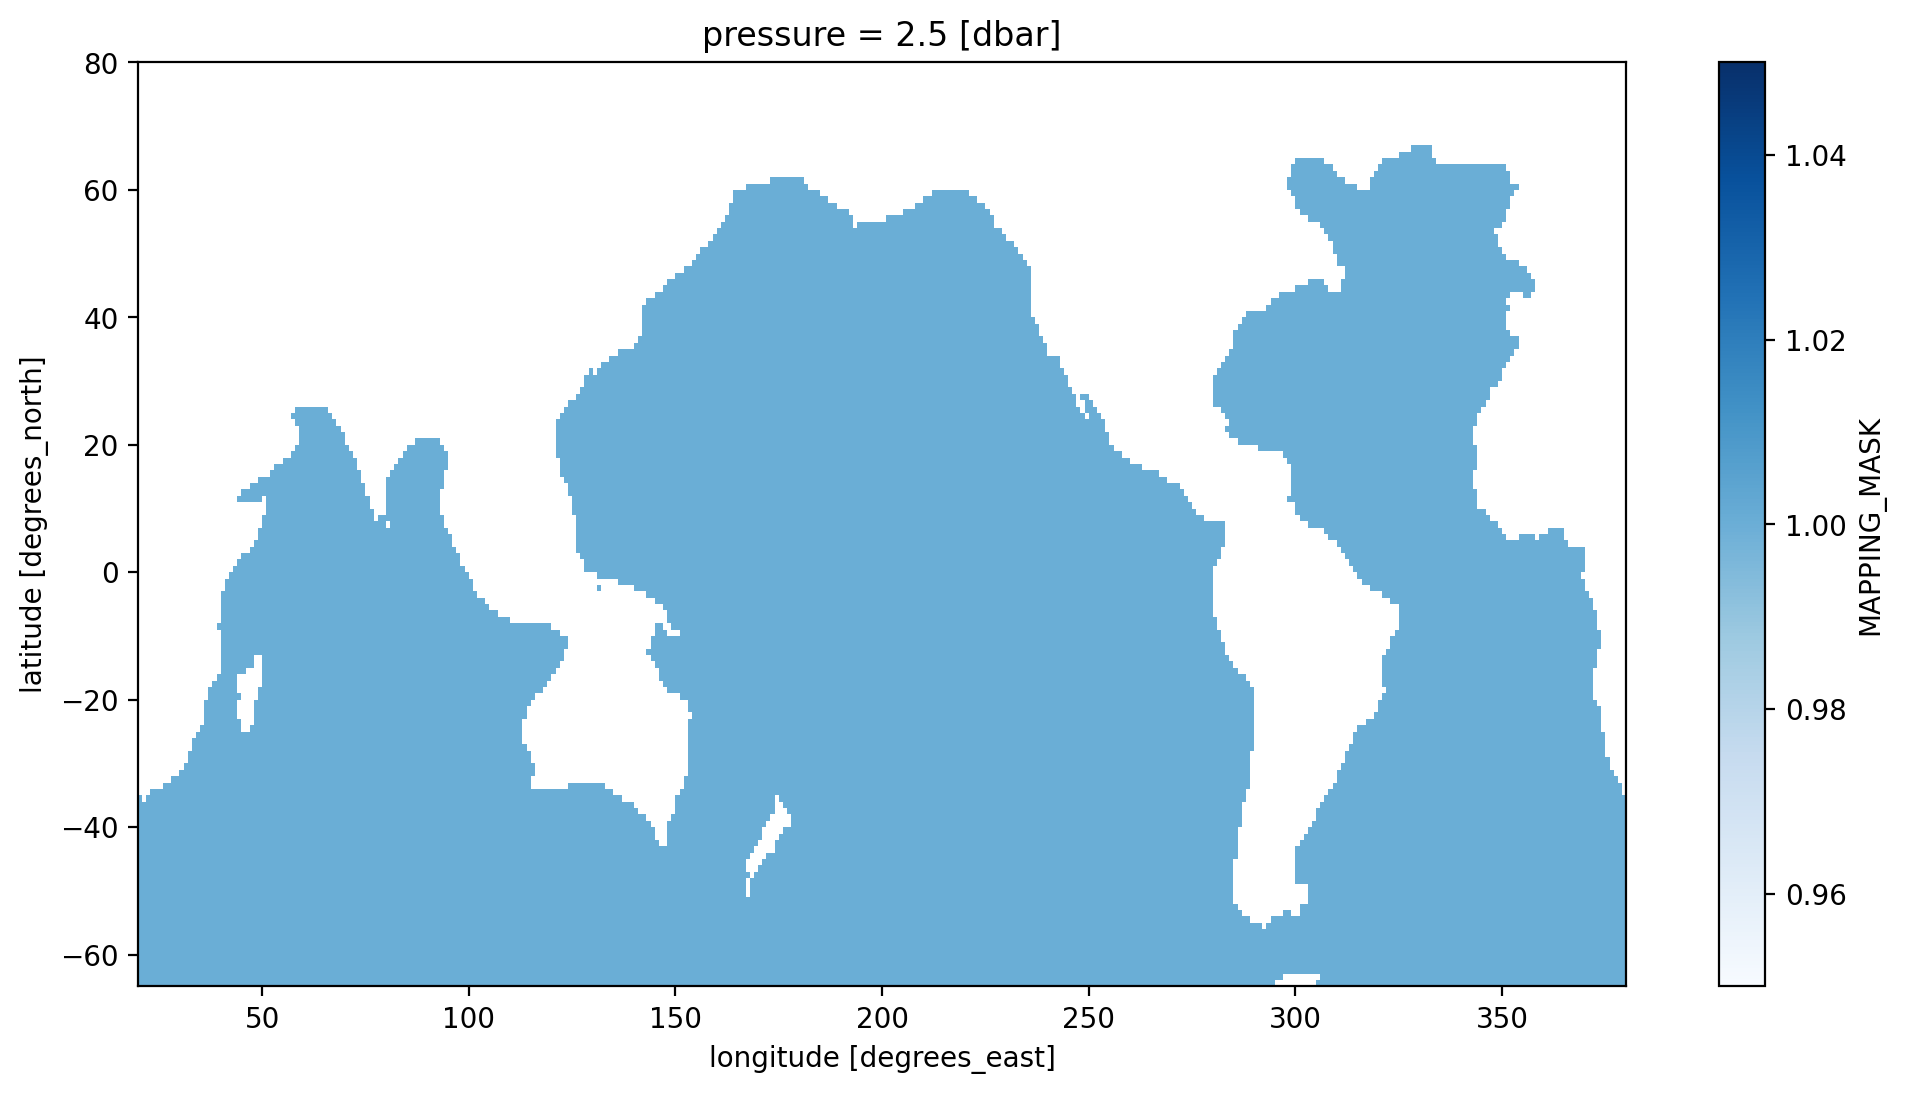

In [10]:
Mask.plot(cmap='Blues')

### Compute Annual Mean 2025 anomalies relative to Jan 2004 to Dec 2022

In [11]:
## 2004 to 2020 climatology
MLD_2004_2020 = RG_MixedLayerProperties.MLD.sel(time=slice('2004-01-31','2020-12-31')).mean(dim='time')

## 2025 annual mean
MLD_2025 = RG_MixedLayerProperties.MLD.sel(time=slice('2025-01-31','2025-12-31')).mean(dim='time')

### Year 2025 Anomalies
MLD_2025_Anom = MLD_2025 - MLD_2004_2020

### Compute annual cycle climatology

In [12]:
MLD_2004_2020_Ann_Clim = (RG_MixedLayerProperties.MLD*Mask).sel(time=slice('2004-01-31','2020-12-31')).groupby('time.month').mean(dim='time')
MLD_2025_Ann_Clim = (RG_MixedLayerProperties.MLD*Mask).sel(time=slice('2025-01-31','2025-12-31')).groupby('time.month').mean(dim='time')

### Properly area-weight

In [13]:
# The following function is used to create weights for the Earths grid space.
import warnings 

def standard_grid_cell_area(lat, lon, rE=6371.0e3):
    """ computes the cell area for a standard spherical grid """

    dLat = lat[1] - lat[0]
    dLon = lon[1] - lon[0]
    area = np.empty((len(lat), len(lon)))
    for j in range(0, len(lat)):
        for i in range(0, len(lon)):
            lon1 = lon[i] + dLon / 2
            lon0 = lon[i] - dLon / 2
            lat1 = lat[j] + dLat / 2
            lat0 = lat[j] - dLat / 2
            area[j, i] = (
                (np.pi / 180.0)
                * rE
                * rE
                * np.abs(np.sin(np.radians(lat0)) - np.sin(np.radians(lat1)))
                * np.abs(lon0 - lon1)
            )
    return area

In [14]:
lat_mld = RG_MixedLayerProperties.coords['latitude'].values #1-D numpy array of model's latitude values
lon_mld = RG_MixedLayerProperties.coords['longitude'].values #1-D numpy array of model's longitude values
areacell = standard_grid_cell_area(lat_mld,lon_mld)

In [15]:
areacell_xarray = xr.DataArray(areacell,dims=({'latitude':145, 'longitude':360}),\
                                                coords=(RG_MixedLayerProperties.coords['latitude'],\
                                                        RG_MixedLayerProperties.coords['longitude']))

In [16]:
weights = areacell_xarray*Mask

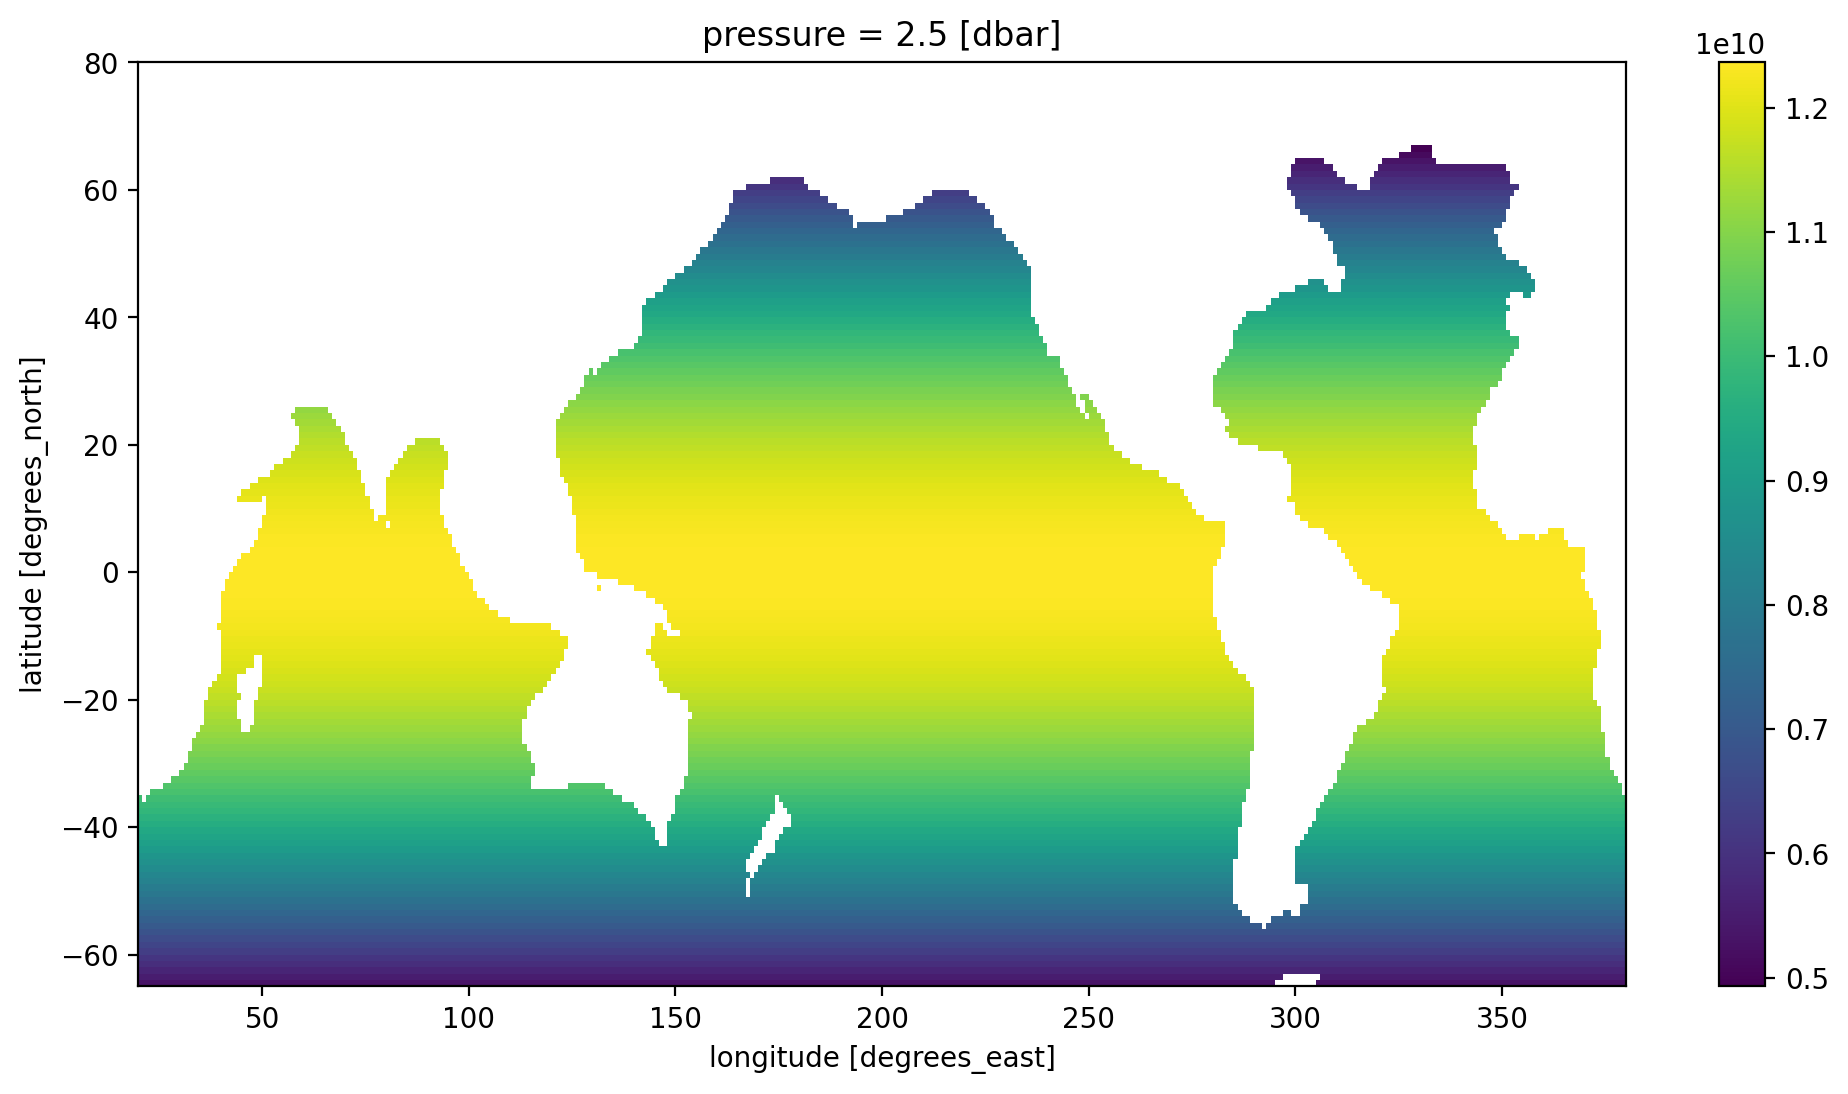

In [17]:
weights.plot()

## Isolate specific regions for regional averages

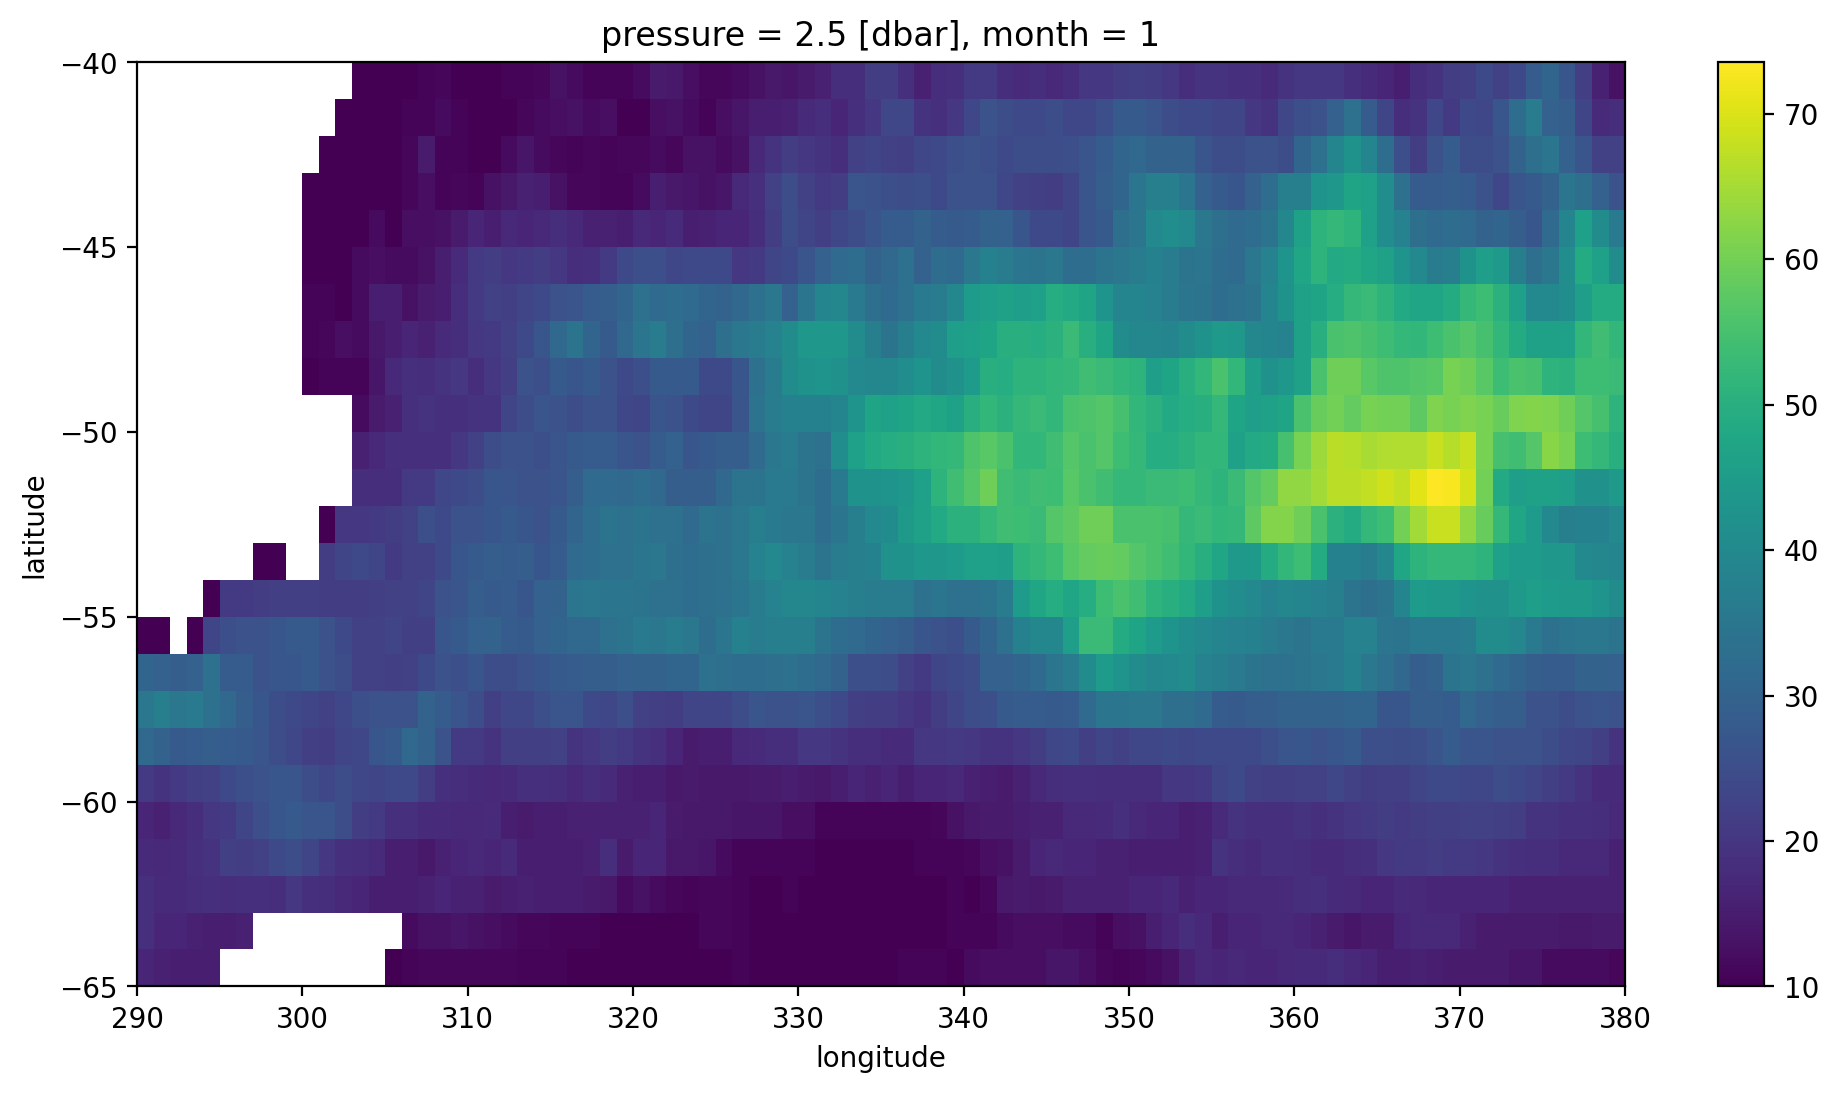

In [18]:
### individually check to confirm my bounds are correct ...
## indian
#MLD_2004_2022_Ann_Clim.isel(month=0).sel(latitude=slice(-65,-40),longitude=slice(20.5,170)).plot()

## west pacific
#MLD_2004_2022_Ann_Clim.isel(month=0).sel(latitude=slice(-65,-40),longitude=slice(170,230)).plot()

## east pacific
#MLD_2004_2022_Ann_Clim.isel(month=0).sel(latitude=slice(-65,-40),longitude=slice(230,290)).plot()

## atlantic
MLD_2004_2020_Ann_Clim.isel(month=0).sel(latitude=slice(-65,-40),longitude=slice(290,385)).plot()

In [19]:
def regional_clim(mld):
    east_pac = mld.sel(latitude=slice(-65,-40),longitude=slice(230,290))
    west_pac = mld.sel(latitude=slice(-65,-40),longitude=slice(170,230))
    ind = mld.sel(latitude=slice(-65,-40),longitude=slice(20.5,170))
    atl = mld.sel(latitude=slice(-65,-40),longitude=slice(290,380))
    so = mld.sel(latitude=slice(-65,-40))
    return east_pac, west_pac, ind, atl, so

In [20]:
mld_2004_20_clim = regional_clim(RG_MixedLayerProperties.MLD.sel(time=slice('2004-01-31','2020-12-31')))
mld_2025_clim = regional_clim(RG_MixedLayerProperties.MLD.sel(time=slice('2025-01-31','2025-12-31')))

In [21]:
east_pac_04_20_clim = mld_2004_20_clim[0].weighted(weights.fillna(0)).mean(dim=['latitude','longitude']).groupby('time.month').mean(dim='time')
west_pac_04_20_clim = mld_2004_20_clim[1].weighted(weights.fillna(0)).mean(dim=['latitude','longitude']).groupby('time.month').mean(dim='time')
ind_04_20_clim = mld_2004_20_clim[2].weighted(weights.fillna(0)).mean(dim=['latitude','longitude']).groupby('time.month').mean(dim='time')
atl_04_20_clim = mld_2004_20_clim[3].weighted(weights.fillna(0)).mean(dim=['latitude','longitude']).groupby('time.month').mean(dim='time')
so_04_20_clim = mld_2004_20_clim[4].weighted(weights.fillna(0)).mean(dim=['latitude','longitude']).groupby('time.month').mean(dim='time')

east_pac_25_clim = mld_2025_clim[0].weighted(weights.fillna(0)).mean(dim=['latitude','longitude']).groupby('time.month').mean(dim='time')
west_pac_25_clim = mld_2025_clim[1].weighted(weights.fillna(0)).mean(dim=['latitude','longitude']).groupby('time.month').mean(dim='time')
ind_25_clim = mld_2025_clim[2].weighted(weights.fillna(0)).mean(dim=['latitude','longitude']).groupby('time.month').mean(dim='time')
atl_25_clim = mld_2025_clim[3].weighted(weights.fillna(0)).mean(dim=['latitude','longitude']).groupby('time.month').mean(dim='time')
so_25_clim = mld_2025_clim[4].weighted(weights.fillna(0)).mean(dim=['latitude','longitude']).groupby('time.month').mean(dim='time')

east_pac_25_anom = east_pac_25_clim - east_pac_04_20_clim
west_pac_25_anom = west_pac_25_clim - west_pac_04_20_clim
ind_25_anom = ind_25_clim - ind_04_20_clim
atl_25_anom = atl_25_clim - atl_04_20_clim
so_25_anom = so_25_clim - so_04_20_clim

### Standard error of the mean

In [22]:
east_pac_04_20_clim_ste = (mld_2004_20_clim[0].weighted(weights.fillna(0)).mean(dim=['latitude','longitude']).groupby('time.month').std(dim='time')
                           /(np.sqrt(len(mld_2004_20_clim[0].groupby('time.year'))))) # divide by number or years
west_pac_04_20_clim_ste = (mld_2004_20_clim[1].weighted(weights.fillna(0)).mean(dim=['latitude','longitude']).groupby('time.month').std(dim='time')
                           /(np.sqrt(len(mld_2004_20_clim[1].groupby('time.year')))))
ind_04_20_clim_ste = (mld_2004_20_clim[2].weighted(weights.fillna(0)).mean(dim=['latitude','longitude']).groupby('time.month').std(dim='time')
                      /(np.sqrt(len(mld_2004_20_clim[2].groupby('time.year')))))
atl_04_20_clim_ste = (mld_2004_20_clim[3].weighted(weights.fillna(0)).mean(dim=['latitude','longitude']).groupby('time.month').std(dim='time')
                      /(np.sqrt(len(mld_2004_20_clim[3].groupby('time.year')))))
so_04_20_clim_ste = (mld_2004_20_clim[4].weighted(weights.fillna(0)).mean(dim=['latitude','longitude']).groupby('time.month').std(dim='time')
                     /(np.sqrt(len(mld_2004_20_clim[4].groupby('time.year')))))

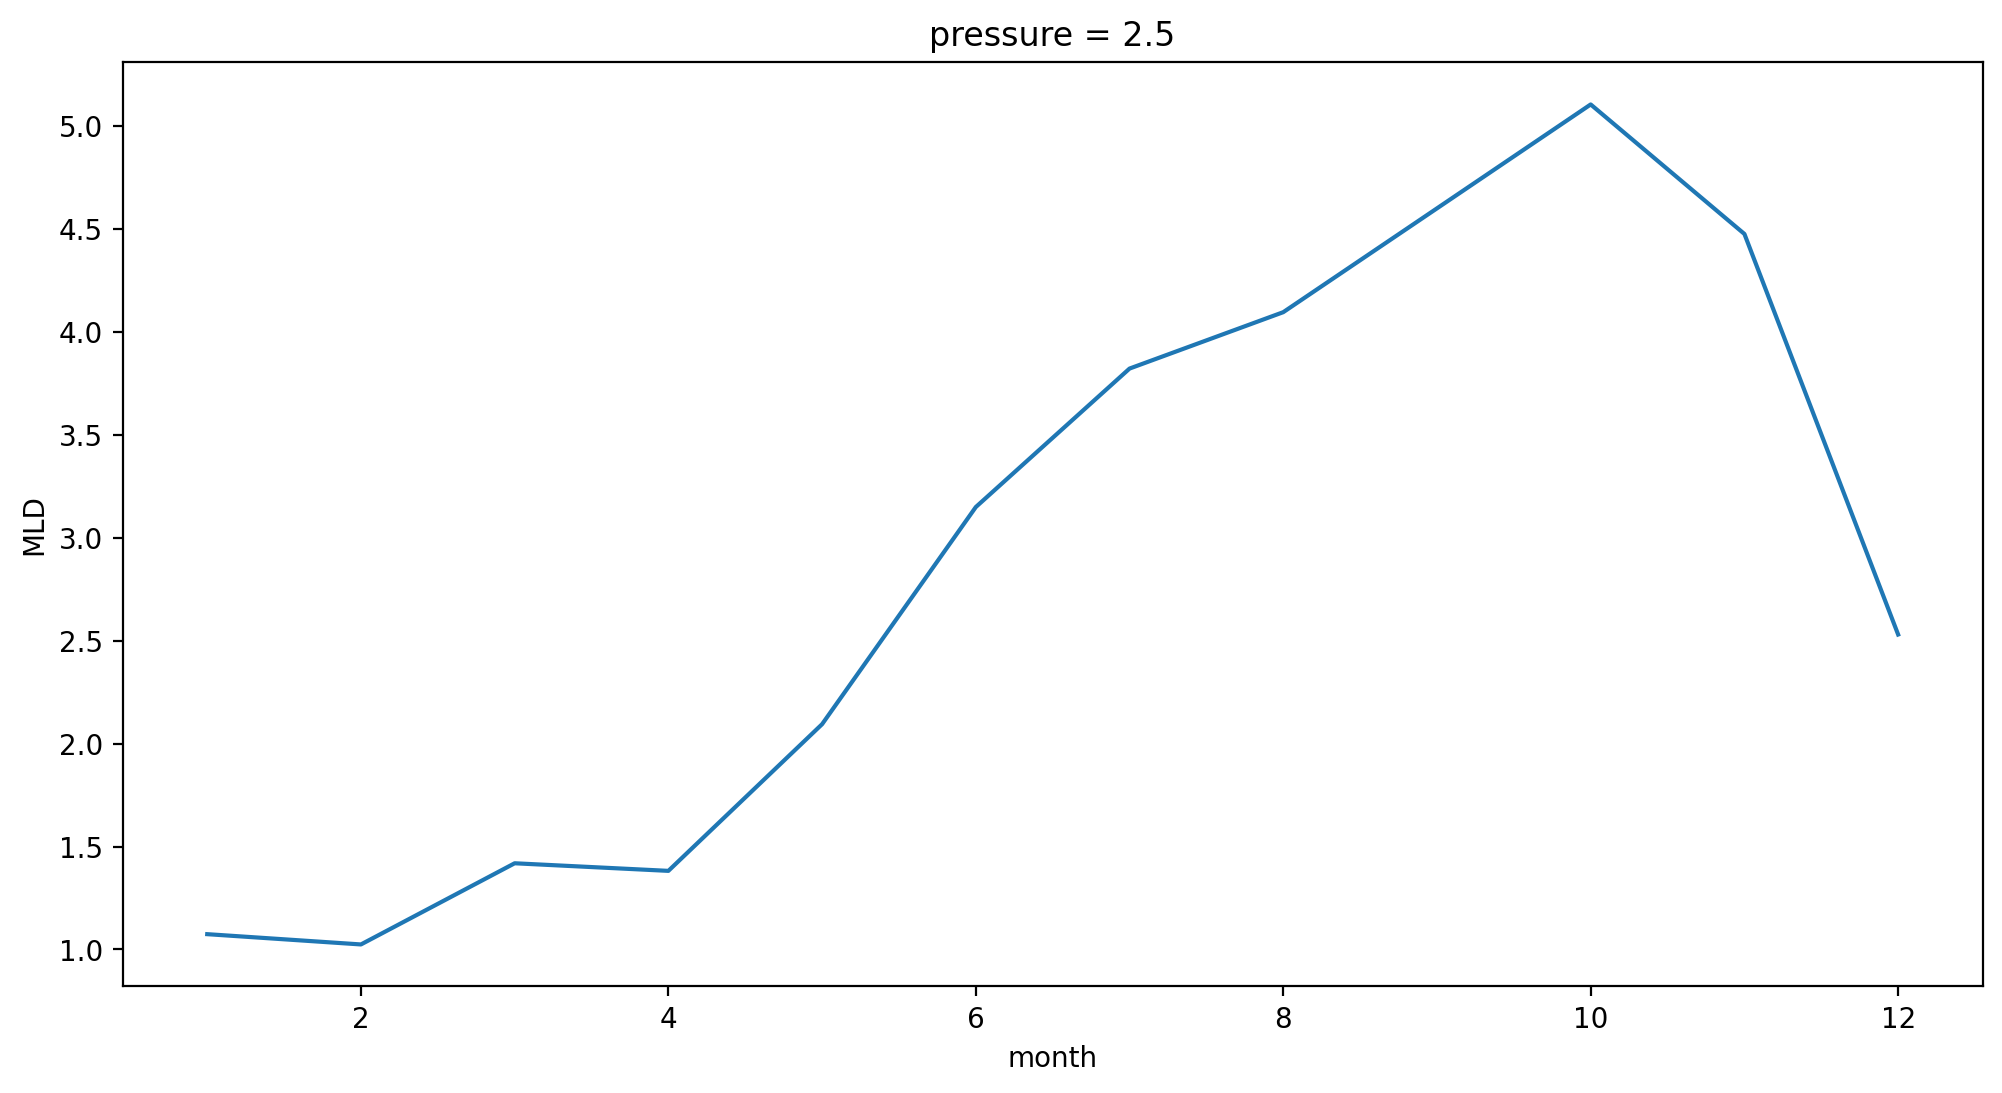

In [23]:
east_pac_04_20_clim_ste.plot()

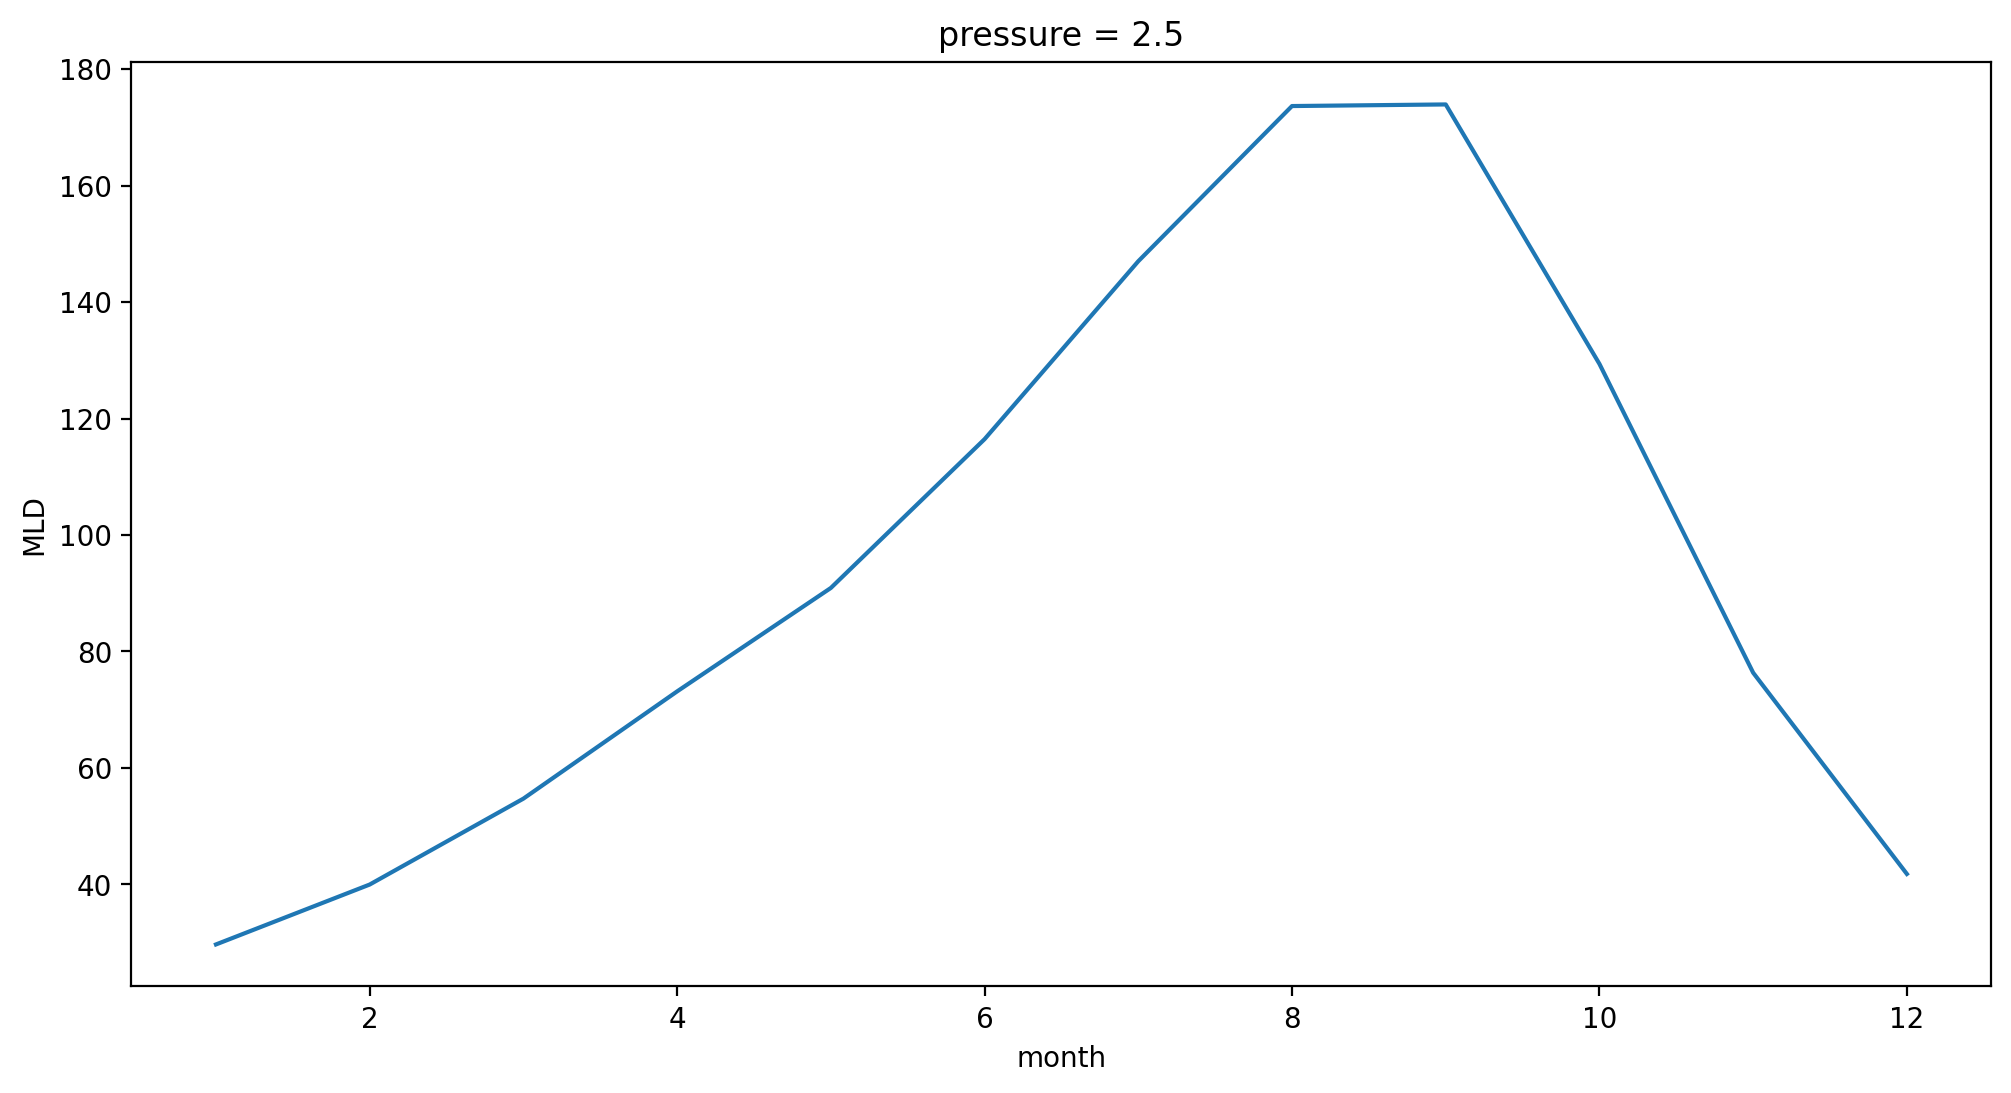

In [24]:
east_pac_04_20_clim.plot()

### Polar Projections showing 2025 anomaly relative to 2004 to 2020 climatology:

In [25]:
def covert2lons360(lons180):
    return lons180%360

In [26]:
## Function to set up Antarctic polar projection:
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)

import matplotlib.ticker as mticker

def antarctic_map(ax, grid, fronts=True):
    ax.set_boundary(circle, transform=ax.transAxes)
    ax.set_extent([-180, 180, -90, -30], ccrs.PlateCarree())
    ax.add_feature(cartopy.feature.LAND, color='grey')
    if grid == True:
        gl = ax.gridlines(linewidth = 0.75, color = 'grey', linestyle = '-')
        gl_so = ax.gridlines(linewidth = 3, color = 'k', linestyle = '--')
        
        ## light grey lat, lon markings
        gl.ylocator = mticker.FixedLocator([-90, -80, -70, -60, -50, -40, -30])
        
        ## southern ocean region
        gl_so.ylocator = mticker.FixedLocator([-65,-40])
        gl_so.xlines = False
    
    ## eastern pacific / atlantic boundary
    eastpac_lon, eastpac_lat = -70, -65
    eastpac_top_lon, eastpac_top_lat = -70, -40
    
    ## western pacific / eastern pacific boundary
    westpac_lon, westpac_lat = -130, -65
    westpac_top_lon, westpac_top_lat = -130, -40
    
    ## western pacific / indian
    westind_lon, westind_lat = 170, -65
    westind_top_lon, westind_top_lat = 170, -40
    
    ## atlantic / indian boundary
    ind_lon, ind_lat = 20, -65
    ind_top_lon, ind_top_lat = 20, -40
    
    ax.plot([eastpac_lon, eastpac_top_lon], [eastpac_lat, eastpac_top_lat],
         color='k', linestyle='--', linewidth=3,
         transform=ccrs.PlateCarree())
    
    ax.plot([westpac_lon, westpac_top_lon], [westpac_lat, westpac_top_lat],
         color='k', linestyle='--', linewidth=3,
         transform=ccrs.PlateCarree())
    
    ax.plot([ind_lon, ind_top_lon], [ind_lat, ind_top_lat],
         color='k', linestyle='--', linewidth=3,
         transform=ccrs.PlateCarree())
    
    ax.plot([westind_lon, westind_top_lon], [westind_lat, westind_top_lat],
         color='k', linestyle='--', linewidth=3,
         transform=ccrs.PlateCarree())
    
    ### put Orsi fronts on plots:
    if fronts==True:

        orsi_pf_coords = np.genfromtxt('/backup/tuq41374/observations/orsi/orsi_fronts/pf.txt', comments='X')
        orsi_saccf_coords = np.genfromtxt('/backup/tuq41374/observations/orsi/orsi_fronts/saccf.txt', comments='X')
        orsi_saf_coords = np.genfromtxt('/backup/tuq41374/observations/orsi/orsi_fronts/saf.txt', comments='X')
        orsi_sbdy_coords = np.genfromtxt('/backup/tuq41374/observations/orsi/orsi_fronts/sbdy.txt', comments='X')
        orsi_stf_coords = np.genfromtxt('/backup/tuq41374/observations/orsi/orsi_fronts/stf.txt', comments='X')

        lons360_pf = covert2lons360(orsi_pf_coords[:,0])
        lons360_saccf = covert2lons360(orsi_saccf_coords[:,0])
        lons360_saf = covert2lons360(orsi_saf_coords[:,0])
        lons360_sbdy = covert2lons360(orsi_sbdy_coords[:,0])
        lons360_stf = covert2lons360(orsi_stf_coords[:,0])
        
        jump_pf = np.flatnonzero(np.diff(lons360_pf)<-10) # to prevent the lines from wrapping longitudinally
        lons360_pf[jump_pf] = np.nan
        
        jump_saccf = np.flatnonzero(np.diff(lons360_saccf)<-10) # to prevent the lines from wrapping longitudinally
        lons360_saccf[jump_saccf] = np.nan
        
        jump_saf = np.flatnonzero(np.diff(lons360_saf)<-10) # to prevent the lines from wrapping longitudinally
        lons360_saf[jump_saf] = np.nan
        
        jump_sbdy = np.flatnonzero(np.diff(lons360_sbdy)<-10) # to prevent the lines from wrapping longitudinally
        lons360_sbdy[jump_sbdy] = np.nan
        
        jump_stf = np.flatnonzero(np.diff(lons360_stf)<-10) # to prevent the lines from wrapping longitudinally
        lons360_stf[jump_stf] = np.nan
        
        ret_pf = ax.projection.transform_points(ccrs.PlateCarree(), lons360_pf, orsi_pf_coords[:,1])
        ret_saccf = ax.projection.transform_points(ccrs.PlateCarree(), lons360_saccf, orsi_saccf_coords[:,1])
        ret_saf = ax.projection.transform_points(ccrs.PlateCarree(), lons360_saf, orsi_saf_coords[:,1])
        ret_sbdy = ax.projection.transform_points(ccrs.PlateCarree(), lons360_sbdy, orsi_sbdy_coords[:,1])
        ret_stf = ax.projection.transform_points(ccrs.PlateCarree(), lons360_stf, orsi_stf_coords[:,1])
        
        #ax.plot(ret_pf[...,0], ret_pf[...,1], color='black', lw=1.5)
        #ax.plot(ret_saccf[...,0], ret_saccf[...,1], color='purple', lw=1.5)
        ax.plot(ret_saf[...,0], ret_saf[...,1], color='purple', lw=3)
        ax.plot(ret_sbdy[...,0], ret_sbdy[...,1], color='purple', lw=3)
        #ax.plot(ret_stf[...,0], ret_stf[...,1], color='orange', lw=1.5)

#reg_coords['Atlantic sector'] = [[-65, -40], [290, 20]]
#reg_coords['Indian sector'] = [[-65, -40], [20, 170]]
#reg_coords['W. Pacific sector'] = [[-65, -40], [170, 230]]
#reg_coords['E. Pacific sector'] = [[-65, -40], [230, 290]]

In [27]:
plt.rcParams['font.family'] = 'DejaVu Sans' #'Arial'
plt.rcParams['font.style'] = 'normal'
plt.rcParams['font.size'] = 12
plt.rcParams['font.weight'] = 'bold'

/tmp/ipykernel_366931/4006242144.py:6: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  ax0= plt.subplot(gs[0,0],projection=ccrs.SouthPolarStereo(),facecolor='white')


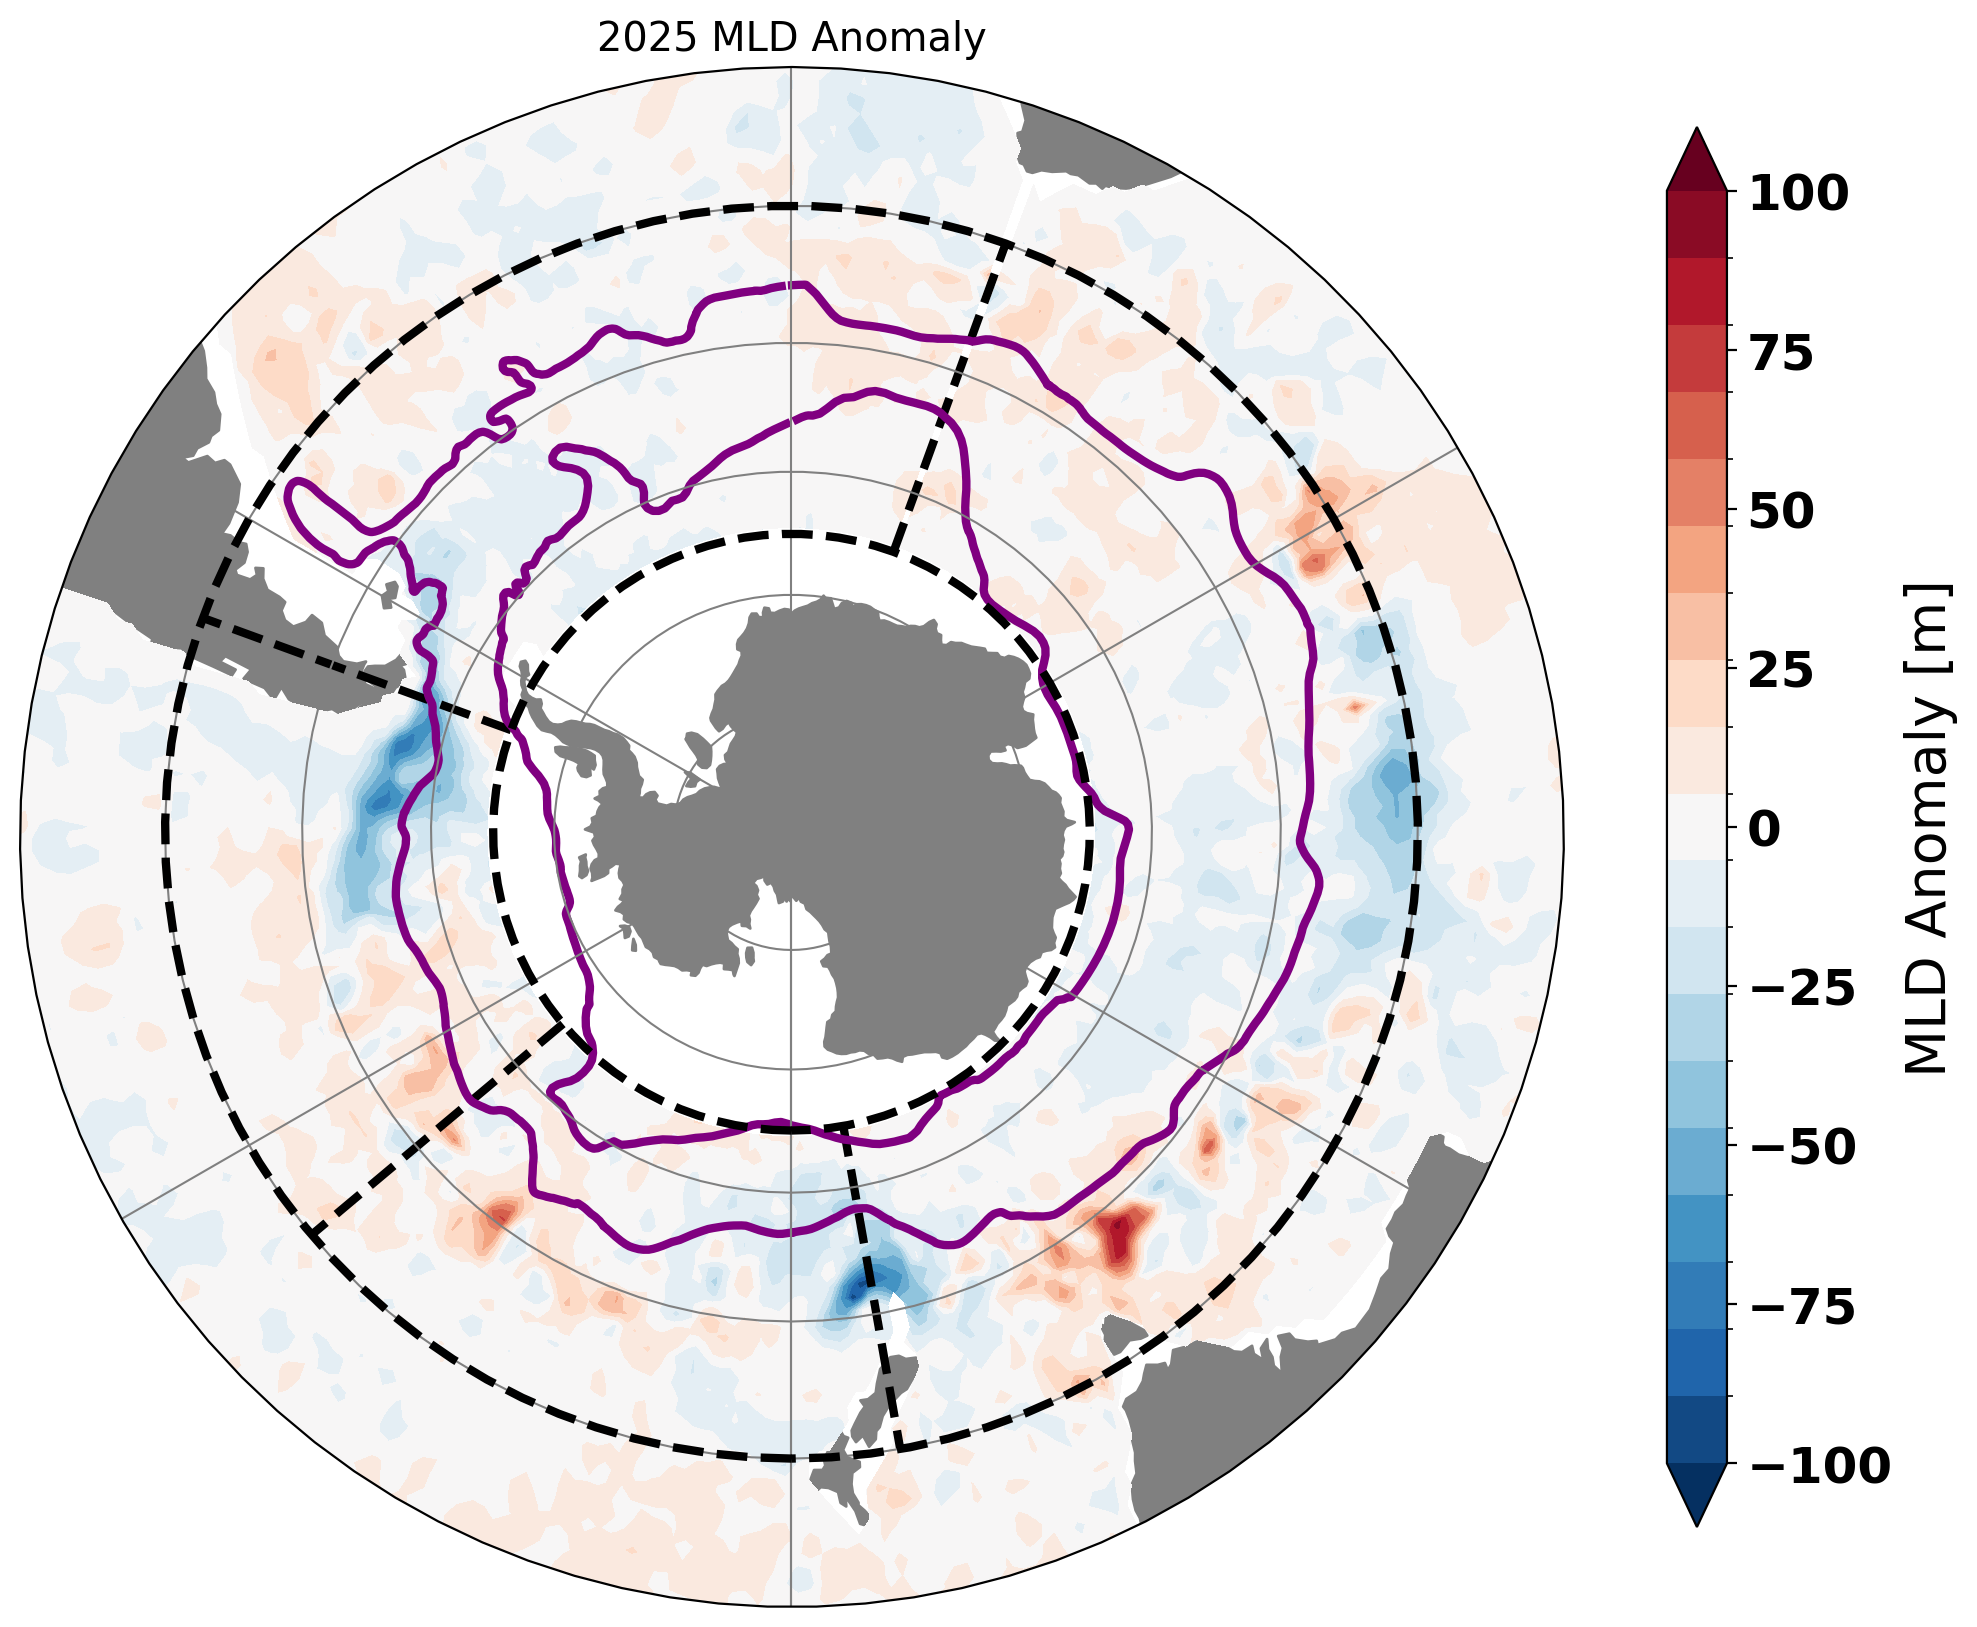

In [29]:
fig, ax  = plt.subplots(1,1, figsize = (10,10))#tight_layout=True)
gs = gridspec.GridSpec(1,1)

#fig.subplots_adjust(wspace=0.30)

ax0= plt.subplot(gs[0,0],projection=ccrs.SouthPolarStereo(),facecolor='white')
#ax1= plt.subplot(gs[0,1])

antarctic_map(ax0, grid = True, fronts=True)
MLD_Anom_levels = np.linspace(-100,100,20)

(MLD_2025_Anom*Mask).plot.contourf(ax=ax0,
                        cmap='RdBu_r',
                        transform=ccrs.PlateCarree(),
                        extend='both',
                        levels=MLD_Anom_levels,
                        add_colorbar=False)


## colorbar

cbr_MLD_Anom = (MLD_2025_Anom*Mask).plot.contourf(ax=ax0,
                        cmap='RdBu_r',
                        transform=ccrs.PlateCarree(),
                        extend='both',
                        levels=MLD_Anom_levels,
                        add_colorbar=False)

### MLD colorbar
cax_MLD_Anom = fig.add_axes([0.95, 0.15, 0.030, 0.70])
cbar_MLD_Anom =plt.colorbar(cbr_MLD_Anom,
                      cax=cax_MLD_Anom,
                      orientation='vertical',
                      shrink=0.5,
                      ticks = [-100,-75,-50,-25,0,25,50,75,100])
cbar_MLD_Anom.ax.tick_params(labelsize=18)
cbar_MLD_Anom.set_label('MLD Anomaly [m]', fontsize=20)
cax_MLD_Anom.yaxis.set_ticks_position('right')
cax_MLD_Anom.yaxis.set_label_position('right')

ax0.set_title('2025 MLD Anomaly')

plt.savefig('MLD_Annual_Mean_Spatial_Rel_2004_2020_NODECEMBER.pdf', bbox_inches='tight')

/tmp/ipykernel_278899/3248336589.py:7: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  ax0=plt.subplot(gs[0,0])


Text(0.5, 1.0, '')

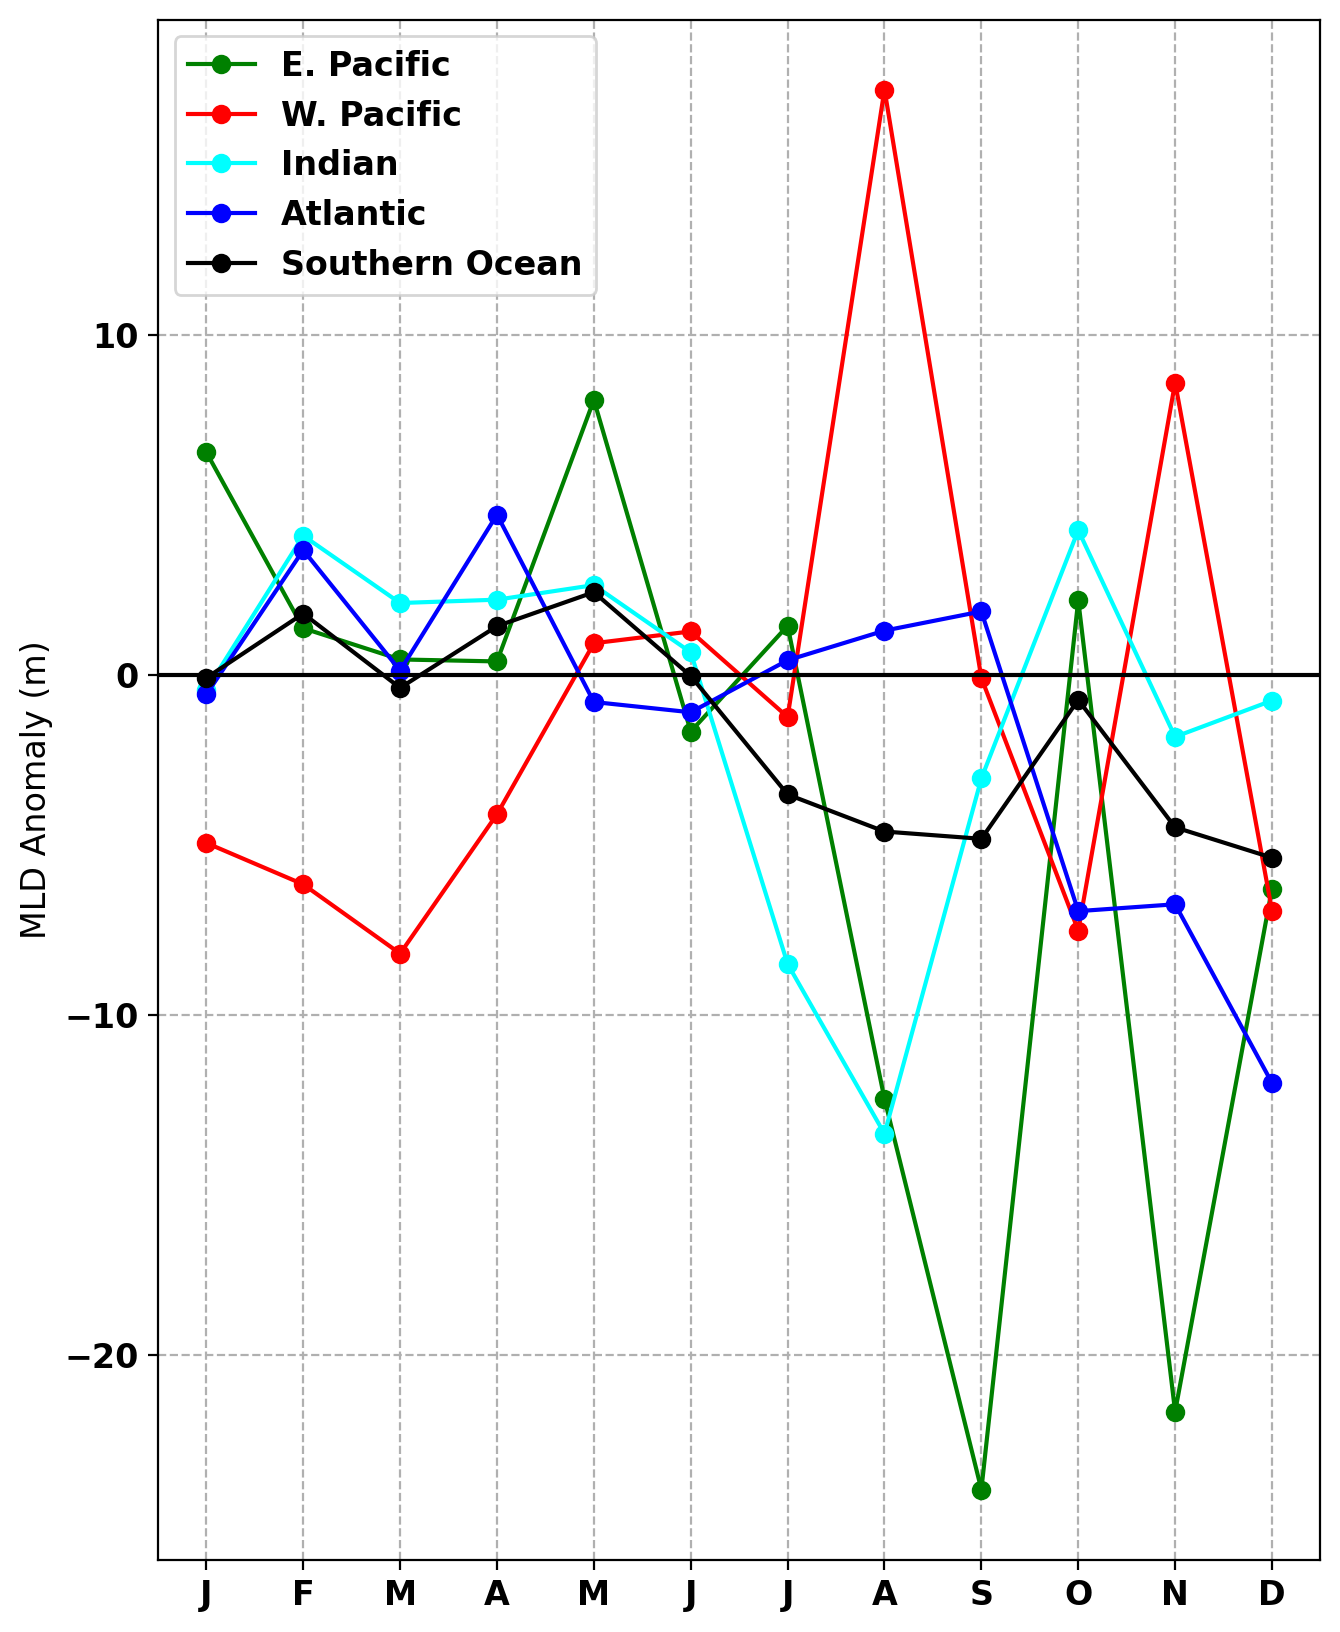

In [32]:
# legend
# no error bars

fig, ax  = plt.subplots(1,1, figsize = (7.5,10))#tight_layout=True)
gs = gridspec.GridSpec(1,1)

ax0=plt.subplot(gs[0,0])

months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
x = np.arange(len(months))

east_pac_anom_months = east_pac_25_anom.drop(labels='month').assign_coords({'month':months})
west_pac_anom_months = west_pac_25_anom.drop(labels='month').assign_coords({'month':months})
ind_anom_months = ind_25_anom.drop(labels='month').assign_coords({'month':months})
atl_anom_months = atl_25_anom.drop(labels='month').assign_coords({'month':months})
so_anom_months = so_25_anom.drop(labels='month').assign_coords({'month':months})

east_pac_anom_months.plot(ax=ax0,color='green',label='E. Pacific',marker='o')
west_pac_anom_months.plot(ax=ax0,color='red',label='W. Pacific',marker='o')
ind_anom_months.plot(ax=ax0,color='cyan',label='Indian',marker='o')
atl_anom_months.plot(ax=ax0,color='blue',label='Atlantic',marker='o')
so_anom_months.plot(ax=ax0,color='k',label='Southern Ocean',marker='o')

## put actual months on the bottom of the x-axis
ax0.axhline(0,color='k')
ax0.grid(linestyle='--')
ax0.set_xlim(months[0], months[-1])
ax0.legend()
ax0.set_ylabel('MLD Anomaly (m)',fontsize=12)
ax0.set_xlabel('',fontsize=12)

ax0.set_xticks(x)
ax0.set_xticklabels(mon[0] for mon in months)
ax0.set_xlim(-0.5, len(months) - 0.5)

ax0.set_title('')

#plt.savefig('MLD_ann_cycle_rel_2004_2020_stder.pdf', bbox_inches='tight')

/tmp/ipykernel_278899/3034595443.py:7: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  ax0=plt.subplot(gs[0,0])


Text(0.5, 1.0, '')

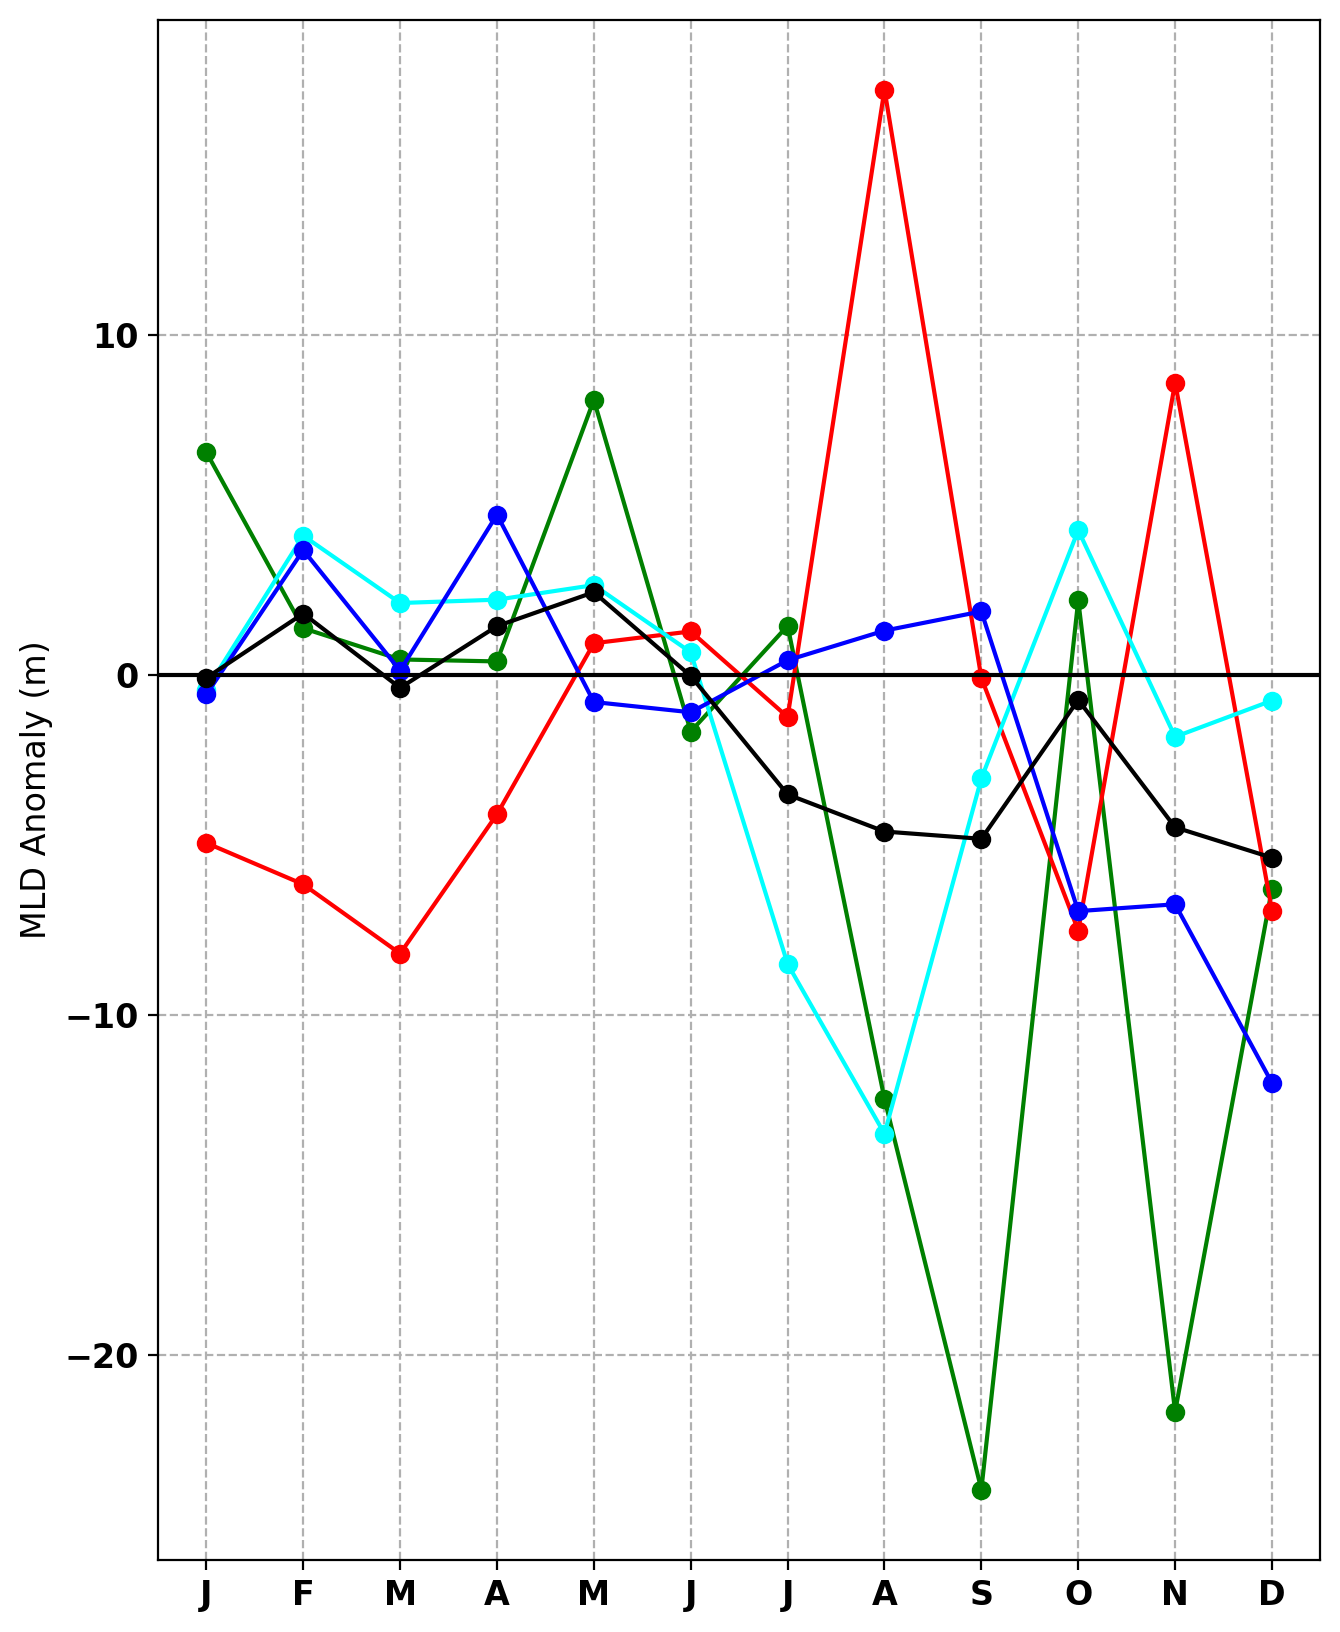

In [33]:
# no legend
# no error bars

fig, ax  = plt.subplots(1,1, figsize = (7.5,10))#tight_layout=True)
gs = gridspec.GridSpec(1,1)

ax0=plt.subplot(gs[0,0])


months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
x = np.arange(len(months))

east_pac_anom_months = east_pac_25_anom.drop(labels='month').assign_coords({'month':months})
west_pac_anom_months = west_pac_25_anom.drop(labels='month').assign_coords({'month':months})
ind_anom_months = ind_25_anom.drop(labels='month').assign_coords({'month':months})
atl_anom_months = atl_25_anom.drop(labels='month').assign_coords({'month':months})
so_anom_months = so_25_anom.drop(labels='month').assign_coords({'month':months})

east_pac_anom_months.plot(ax=ax0,color='green',label='E. Pacific',marker='o')
west_pac_anom_months.plot(ax=ax0,color='red',label='W. Pacific',marker='o')
ind_anom_months.plot(ax=ax0,color='cyan',label='Indian',marker='o')
atl_anom_months.plot(ax=ax0,color='blue',label='Atlantic',marker='o')
so_anom_months.plot(ax=ax0,color='k',label='Southern Ocean',marker='o')

## put actual months on the bottom of the x-axis
ax0.axhline(0,color='k')
ax0.grid(linestyle='--')
ax0.set_xlim(months[0], months[-1])
# ax0.legend()
ax0.set_ylabel('MLD Anomaly (m)',fontsize=12)
ax0.set_xlabel('',fontsize=12)

ax0.set_xticks(x)
ax0.set_xticklabels(mon[0] for mon in months)
ax0.set_xlim(-0.5, len(months) - 0.5)

ax0.set_title('')

#plt.savefig('MLD_ann_cycle_rel_2004_2020_stder.pdf', bbox_inches='tight')

/tmp/ipykernel_278899/3577112686.py:8: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  ax0=plt.subplot(gs[0,0])


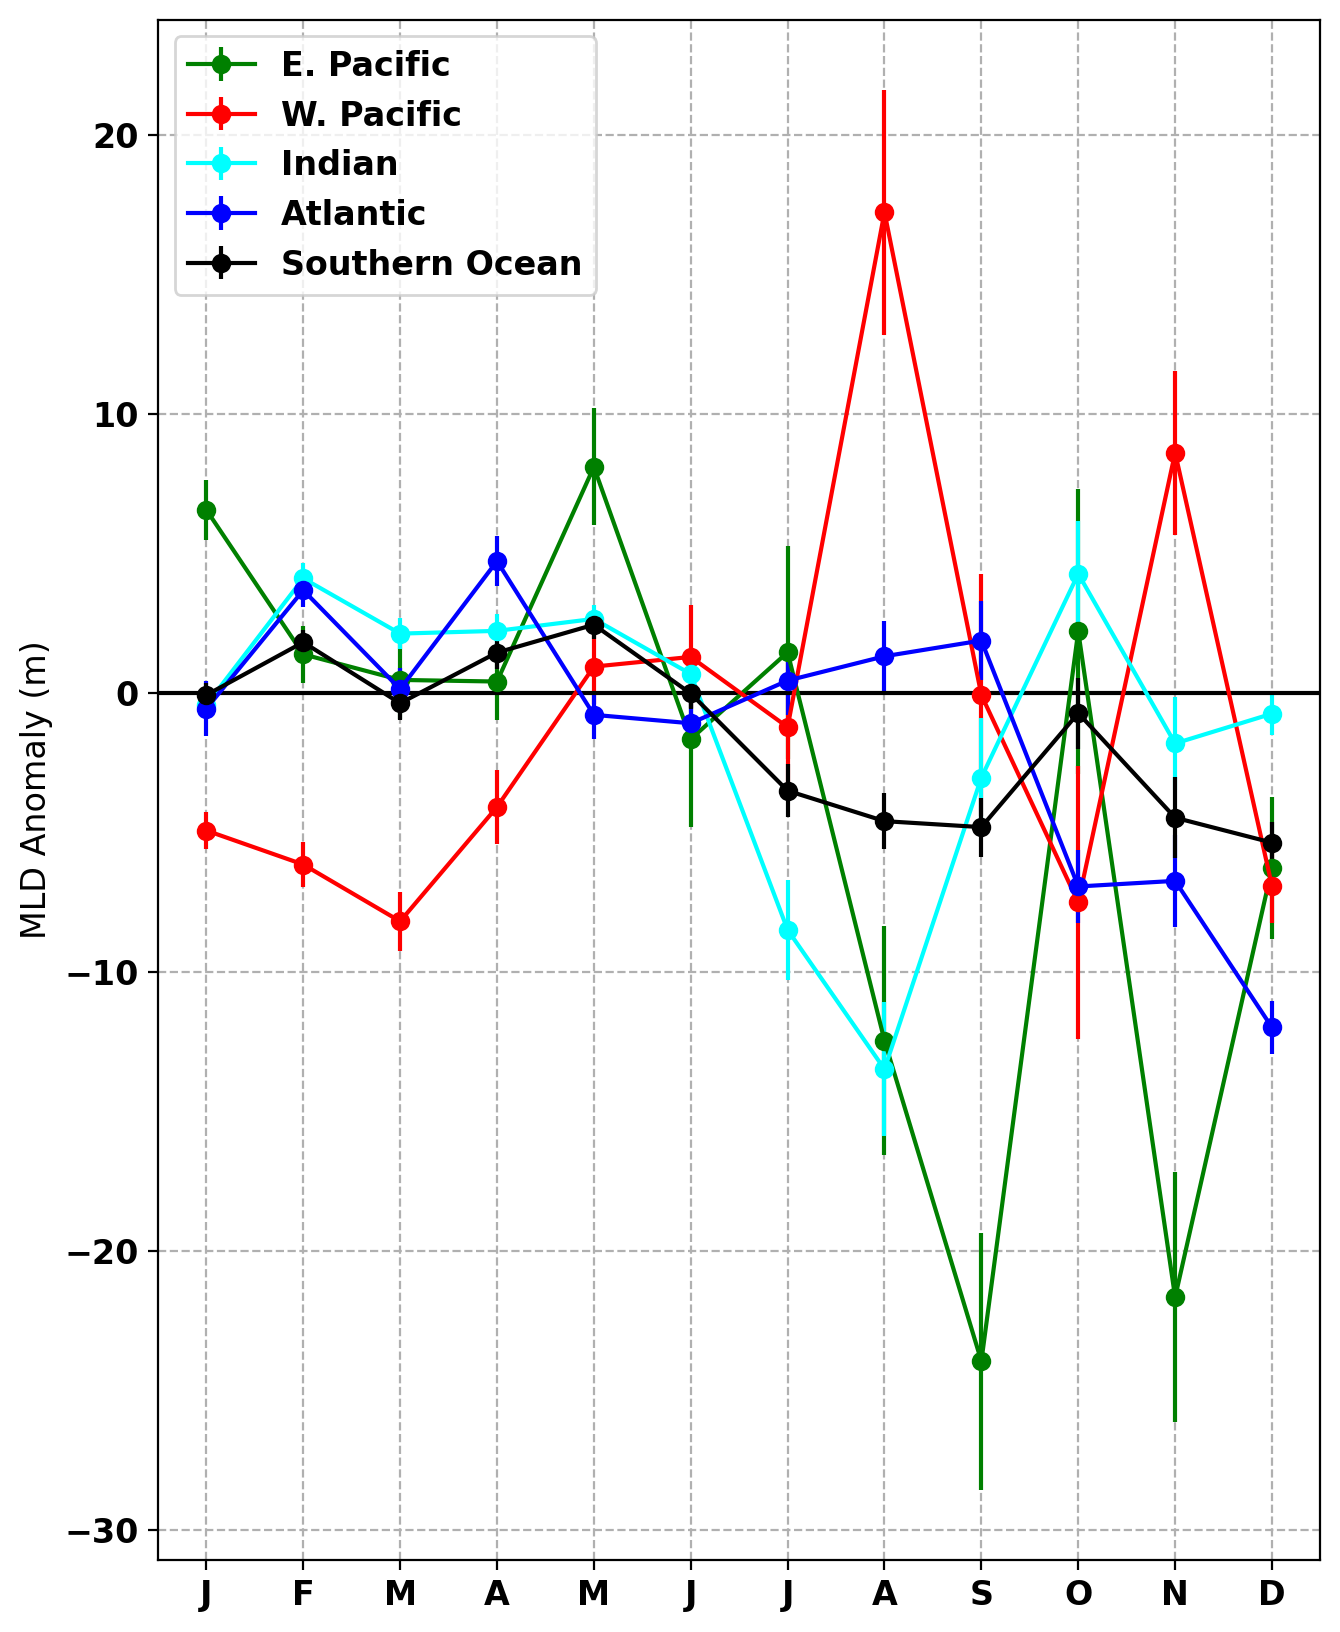

In [42]:
# legend
# error bars
# no error caps

fig, ax  = plt.subplots(1,1, figsize = (7.5,10))#tight_layout=True)
gs = gridspec.GridSpec(1,1)

ax0=plt.subplot(gs[0,0])


months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
x = np.arange(len(months))

east_pac_anom_months = east_pac_25_anom.drop(labels='month').assign_coords({'month':months})
west_pac_anom_months = west_pac_25_anom.drop(labels='month').assign_coords({'month':months})
ind_anom_months = ind_25_anom.drop(labels='month').assign_coords({'month':months})
atl_anom_months = atl_25_anom.drop(labels='month').assign_coords({'month':months})
so_anom_months = so_25_anom.drop(labels='month').assign_coords({'month':months})


east_pac_ste_months = east_pac_04_20_clim_ste.drop(labels='month').assign_coords({'month':months})
west_pac_ste_months = west_pac_04_20_clim_ste.drop(labels='month').assign_coords({'month':months})
ind_clim_ste_months = ind_04_20_clim_ste.drop(labels='month').assign_coords({'month':months})
atl_clim_ste_months = atl_04_20_clim_ste.drop(labels='month').assign_coords({'month':months})
so_clim_ste_months = so_04_20_clim_ste.drop(labels='month').assign_coords({'month':months})



ax0.errorbar(x=months,y=east_pac_anom_months,yerr=east_pac_04_20_clim_ste,color='green',label='E. Pacific',marker='o')
ax0.errorbar(x=months,y=west_pac_anom_months,yerr=west_pac_04_20_clim_ste,color='red',label='W. Pacific',marker='o')
ax0.errorbar(x=months,y=ind_anom_months,yerr=ind_04_20_clim_ste,color='cyan',label='Indian',marker='o')
ax0.errorbar(x=months,y=atl_anom_months,yerr=atl_04_20_clim_ste,color='blue',label='Atlantic',marker='o')
ax0.errorbar(x=months,y=so_anom_months,yerr=so_04_20_clim_ste,color='k',label='Southern Ocean',marker='o')


## put actual months on the bottom of the x-axis
ax0.axhline(0,color='k')
ax0.grid(linestyle='--')
ax0.set_xlim(months[0], months[-1])
ax0.legend()
ax0.set_ylabel('MLD Anomaly (m)',fontsize=12)
ax0.set_xlabel('',fontsize=12)

ax0.set_xticks(x)
ax0.set_xticklabels(mon[0] for mon in months)
ax0.set_xlim(-0.5, len(months) - 0.5)


ax0.set_title('')

plt.savefig('MLD_ann_cycle_rel_2004_2020_stder_NODECEMBER.pdf', bbox_inches='tight')

/tmp/ipykernel_278899/641578976.py:8: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  ax0=plt.subplot(gs[0,0])


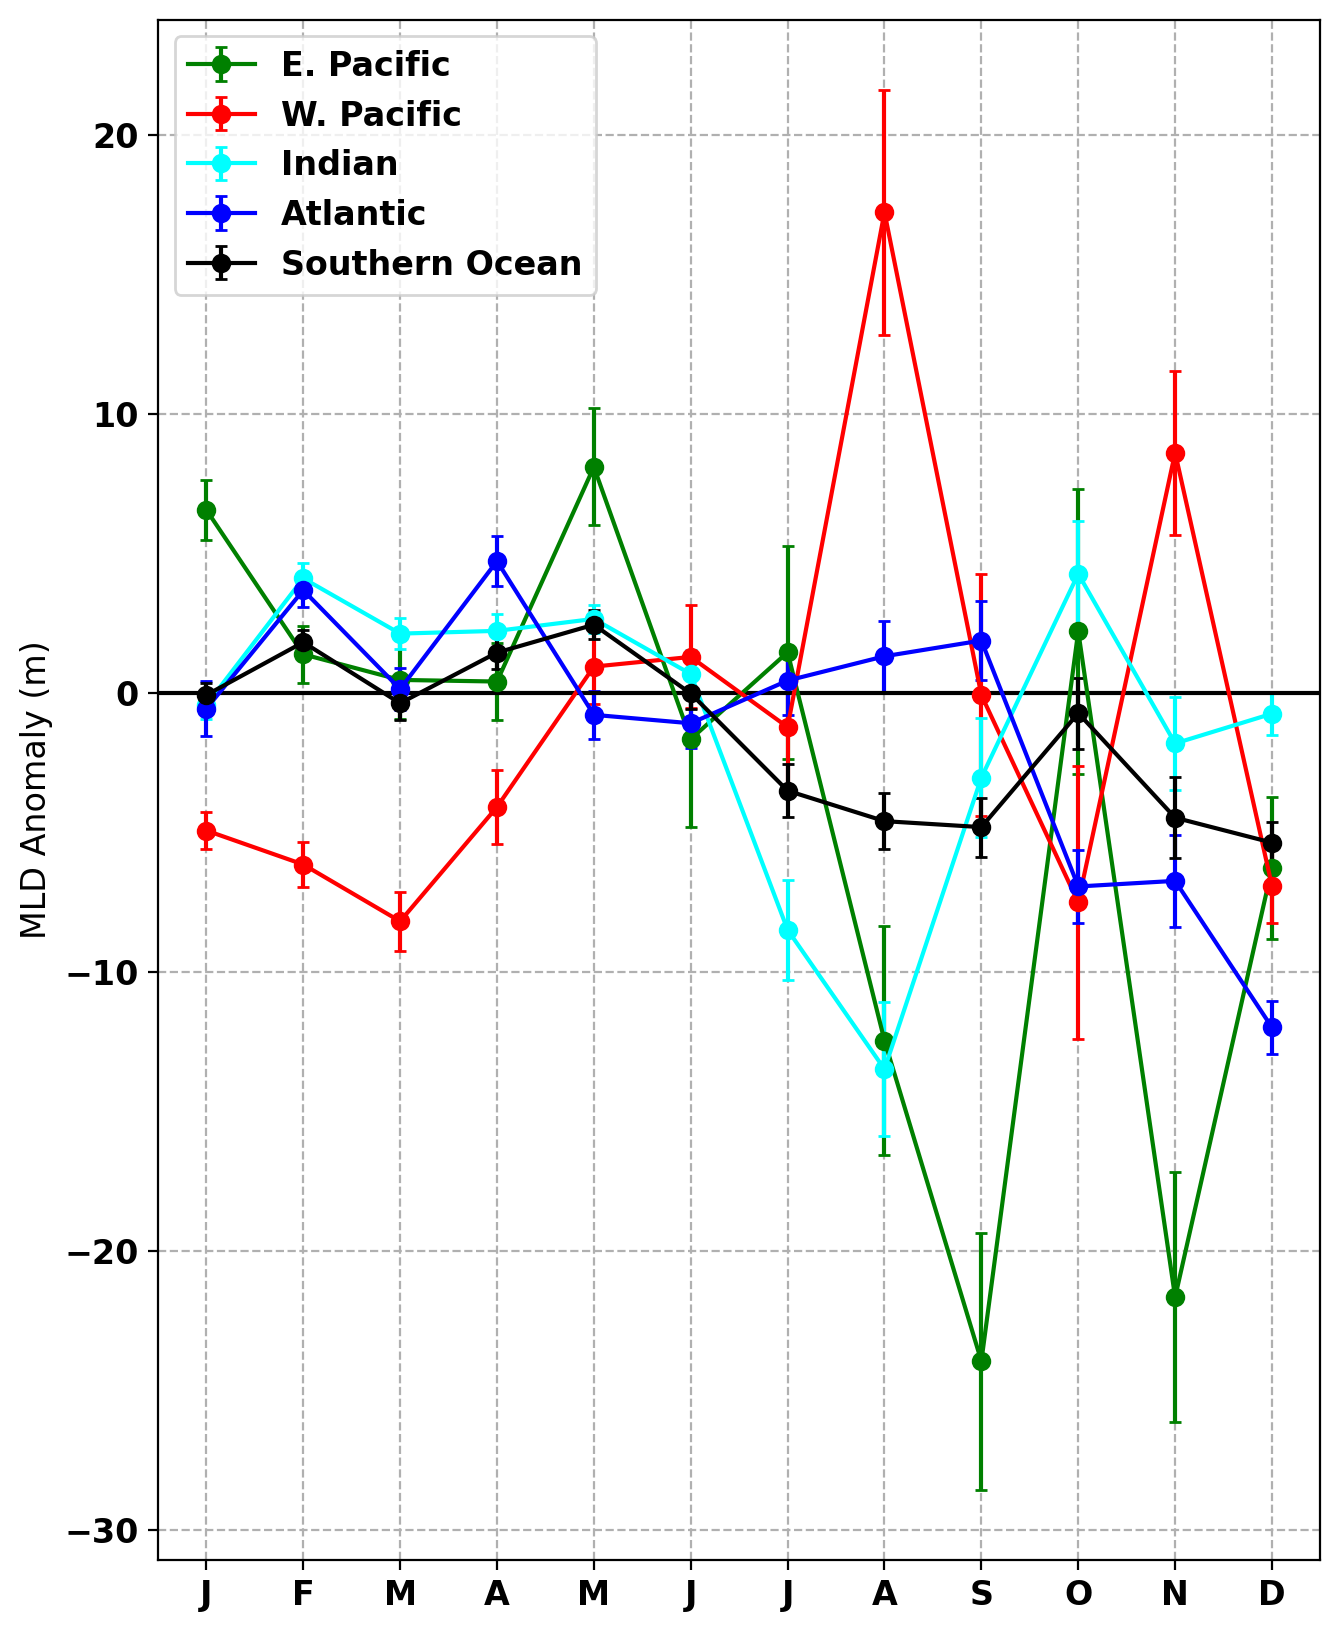

In [35]:
# legend
# error bars
# error caps

fig, ax  = plt.subplots(1,1, figsize = (7.5,10))#tight_layout=True)
gs = gridspec.GridSpec(1,1)

ax0=plt.subplot(gs[0,0])


months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
x = np.arange(len(months))

east_pac_anom_months = east_pac_25_anom.drop(labels='month').assign_coords({'month':months})
west_pac_anom_months = west_pac_25_anom.drop(labels='month').assign_coords({'month':months})
ind_anom_months = ind_25_anom.drop(labels='month').assign_coords({'month':months})
atl_anom_months = atl_25_anom.drop(labels='month').assign_coords({'month':months})
so_anom_months = so_25_anom.drop(labels='month').assign_coords({'month':months})


east_pac_ste_months = east_pac_04_20_clim_ste.drop(labels='month').assign_coords({'month':months})
west_pac_ste_months = west_pac_04_20_clim_ste.drop(labels='month').assign_coords({'month':months})
ind_clim_ste_months = ind_04_20_clim_ste.drop(labels='month').assign_coords({'month':months})
atl_clim_ste_months = atl_04_20_clim_ste.drop(labels='month').assign_coords({'month':months})
so_clim_ste_months = so_04_20_clim_ste.drop(labels='month').assign_coords({'month':months})



ax0.errorbar(x,y=east_pac_anom_months,yerr=east_pac_04_20_clim_ste,color='green',label='E. Pacific',marker='o', capsize=2)
ax0.errorbar(x,y=west_pac_anom_months,yerr=west_pac_04_20_clim_ste,color='red',label='W. Pacific',marker='o', capsize=2)
ax0.errorbar(x,y=ind_anom_months,yerr=ind_04_20_clim_ste,color='cyan',label='Indian',marker='o', capsize=2)
ax0.errorbar(x,y=atl_anom_months,yerr=atl_04_20_clim_ste,color='blue',label='Atlantic',marker='o', capsize=2)
ax0.errorbar(x,y=so_anom_months,yerr=so_04_20_clim_ste,color='k',label='Southern Ocean',marker='o', capsize=2)


## put actual months on the bottom of the x-axis
ax0.axhline(0,color='k')
ax0.grid(linestyle='--')
ax0.set_xlim(months[0], months[-1])
ax0.legend()
ax0.set_ylabel('MLD Anomaly (m)',fontsize=12)
ax0.set_xlabel('',fontsize=12)

ax0.set_xticks(x)
ax0.set_xticklabels(mon[0] for mon in months)
ax0.set_xlim(-0.5, len(months) - 0.5)


ax0.set_title('')

plt.savefig('MLD_ann_cycle_rel_2004_2020_stder_NODECEMBER.pdf', bbox_inches='tight')

/tmp/ipykernel_278899/1864436233.py:8: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  ax0=plt.subplot(gs[0,0])


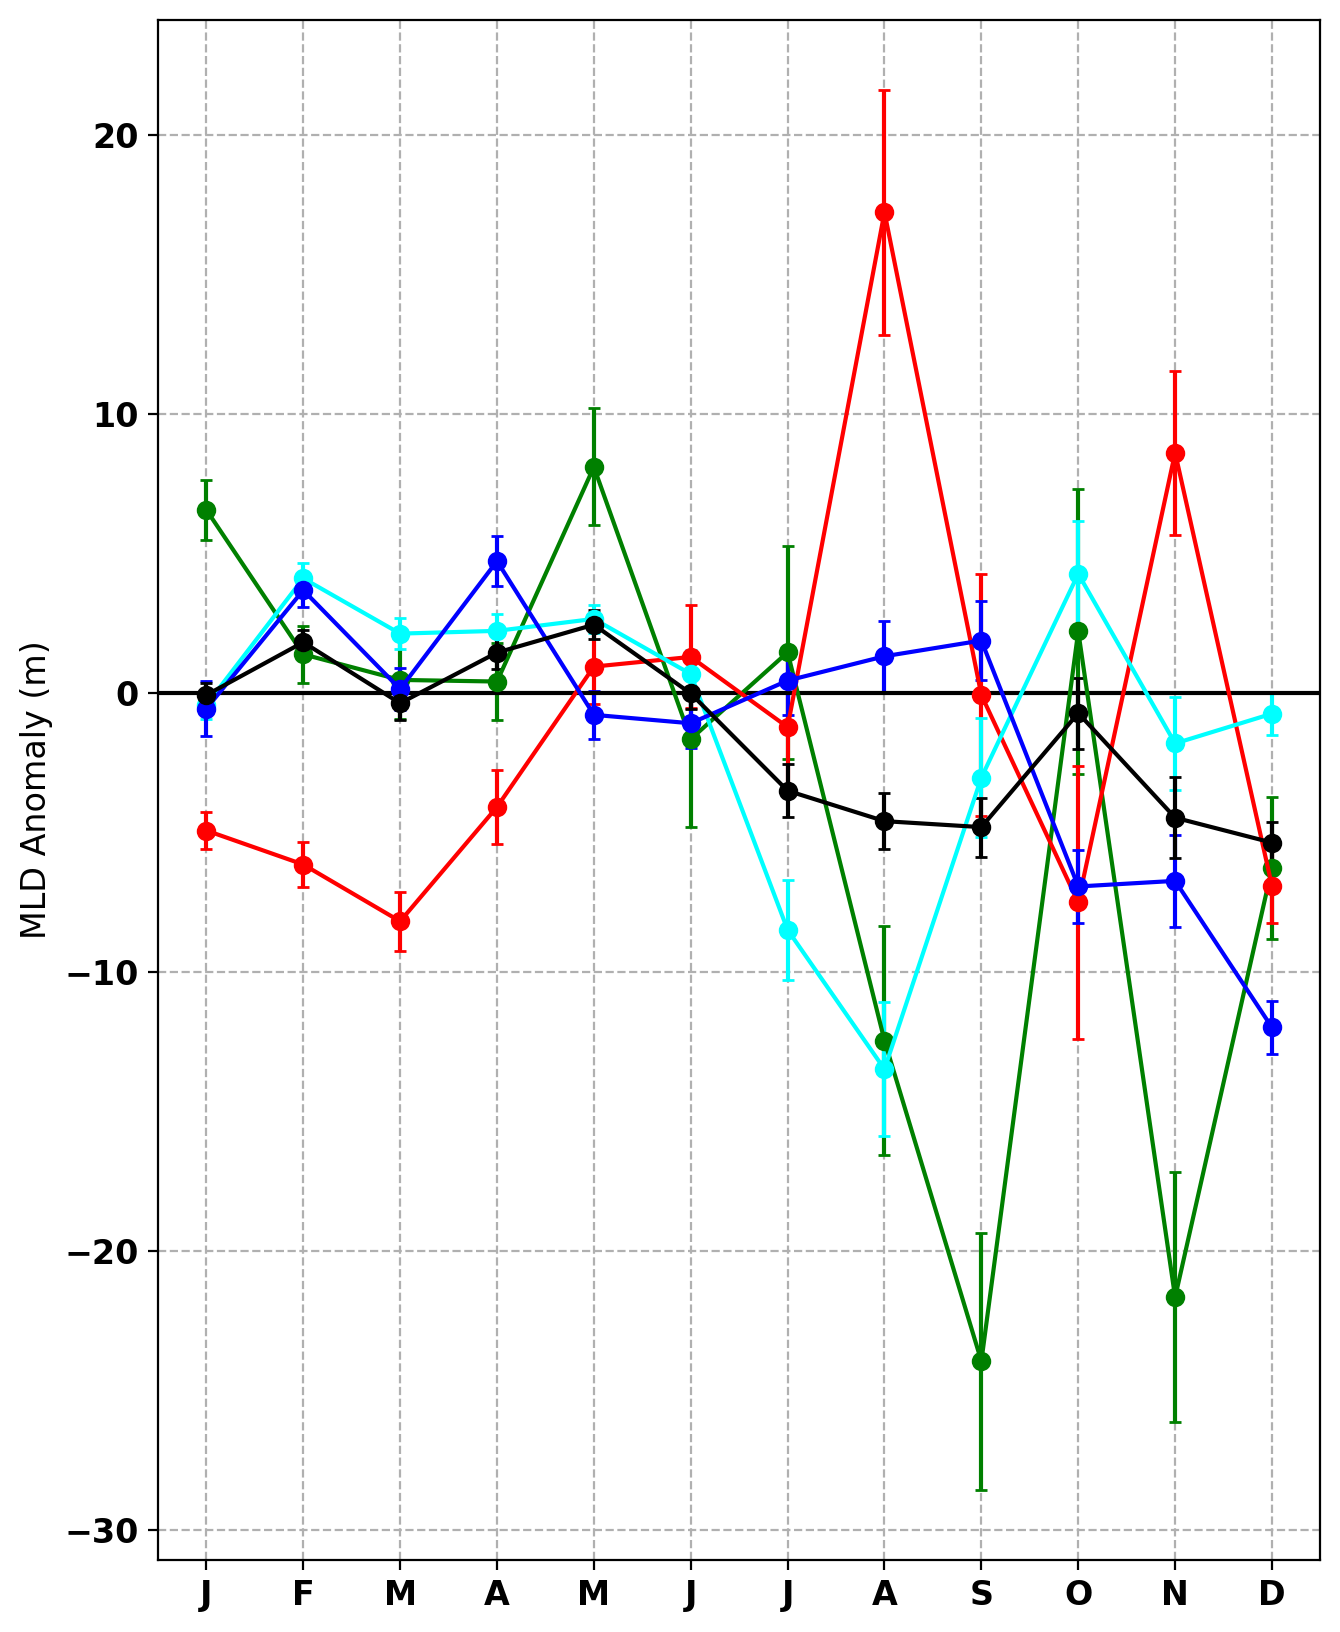

In [39]:
# no legend
# error bars
# error caps

fig, ax  = plt.subplots(1,1, figsize = (7.5,10))#tight_layout=True)
gs = gridspec.GridSpec(1,1)

ax0=plt.subplot(gs[0,0])


months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
x = np.arange(len(months))

east_pac_anom_months = east_pac_25_anom.drop(labels='month').assign_coords({'month':months})
west_pac_anom_months = west_pac_25_anom.drop(labels='month').assign_coords({'month':months})
ind_anom_months = ind_25_anom.drop(labels='month').assign_coords({'month':months})
atl_anom_months = atl_25_anom.drop(labels='month').assign_coords({'month':months})
so_anom_months = so_25_anom.drop(labels='month').assign_coords({'month':months})


east_pac_ste_months = east_pac_04_20_clim_ste.drop(labels='month').assign_coords({'month':months})
west_pac_ste_months = west_pac_04_20_clim_ste.drop(labels='month').assign_coords({'month':months})
ind_clim_ste_months = ind_04_20_clim_ste.drop(labels='month').assign_coords({'month':months})
atl_clim_ste_months = atl_04_20_clim_ste.drop(labels='month').assign_coords({'month':months})
so_clim_ste_months = so_04_20_clim_ste.drop(labels='month').assign_coords({'month':months})



ax0.errorbar(x,y=east_pac_anom_months,yerr=east_pac_04_20_clim_ste,color='green',label='E. Pacific',marker='o', capsize=2)
ax0.errorbar(x,y=west_pac_anom_months,yerr=west_pac_04_20_clim_ste,color='red',label='W. Pacific',marker='o', capsize=2)
ax0.errorbar(x,y=ind_anom_months,yerr=ind_04_20_clim_ste,color='cyan',label='Indian',marker='o', capsize=2)
ax0.errorbar(x,y=atl_anom_months,yerr=atl_04_20_clim_ste,color='blue',label='Atlantic',marker='o', capsize=2)
ax0.errorbar(x,y=so_anom_months,yerr=so_04_20_clim_ste,color='k',label='Southern Ocean',marker='o', capsize=2)


## put actual months on the bottom of the x-axis
ax0.axhline(0,color='k')
ax0.grid(linestyle='--')
ax0.set_xlim(months[0], months[-1])
# ax0.legend()
ax0.set_ylabel('MLD Anomaly (m)',fontsize=12)
ax0.set_xlabel('',fontsize=12)

ax0.set_xticks(x)
ax0.set_xticklabels(mon[0] for mon in months)
ax0.set_xlim(-0.5, len(months) - 0.5)


ax0.set_title('')

plt.savefig('MLD_ann_cycle_rel_2004_2020_stder_NODECEMBER.pdf', bbox_inches='tight')

/tmp/ipykernel_278899/4266325895.py:8: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  ax0=plt.subplot(gs[0,0])


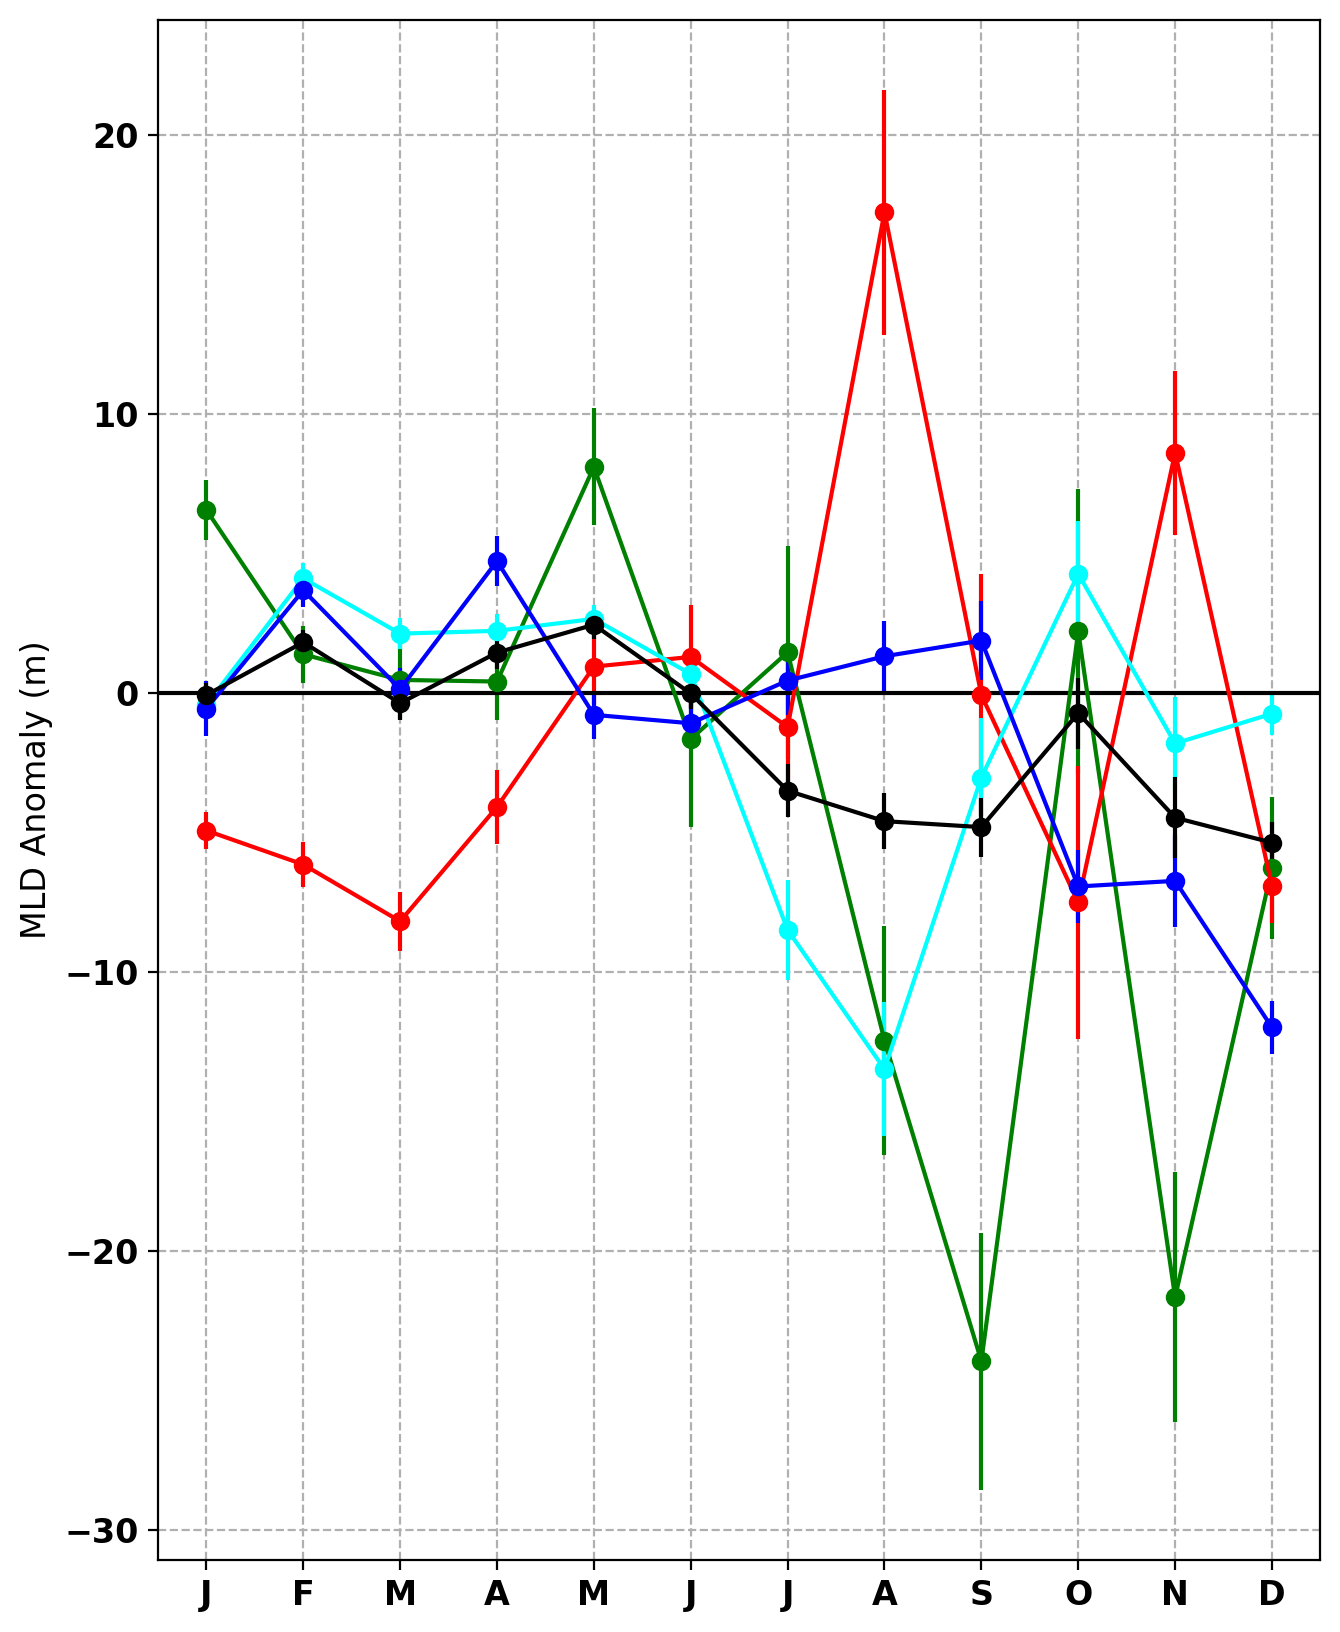

In [38]:
# no legend
# error bars
# no error caps

fig, ax  = plt.subplots(1,1, figsize = (7.5,10))#tight_layout=True)
gs = gridspec.GridSpec(1,1)

ax0=plt.subplot(gs[0,0])


months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
x = np.arange(len(months))

east_pac_anom_months = east_pac_25_anom.drop(labels='month').assign_coords({'month':months})
west_pac_anom_months = west_pac_25_anom.drop(labels='month').assign_coords({'month':months})
ind_anom_months = ind_25_anom.drop(labels='month').assign_coords({'month':months})
atl_anom_months = atl_25_anom.drop(labels='month').assign_coords({'month':months})
so_anom_months = so_25_anom.drop(labels='month').assign_coords({'month':months})


east_pac_ste_months = east_pac_04_20_clim_ste.drop(labels='month').assign_coords({'month':months})
west_pac_ste_months = west_pac_04_20_clim_ste.drop(labels='month').assign_coords({'month':months})
ind_clim_ste_months = ind_04_20_clim_ste.drop(labels='month').assign_coords({'month':months})
atl_clim_ste_months = atl_04_20_clim_ste.drop(labels='month').assign_coords({'month':months})
so_clim_ste_months = so_04_20_clim_ste.drop(labels='month').assign_coords({'month':months})



ax0.errorbar(x,y=east_pac_anom_months,yerr=east_pac_04_20_clim_ste,color='green',label='E. Pacific',marker='o')
ax0.errorbar(x,y=west_pac_anom_months,yerr=west_pac_04_20_clim_ste,color='red',label='W. Pacific',marker='o')
ax0.errorbar(x,y=ind_anom_months,yerr=ind_04_20_clim_ste,color='cyan',label='Indian',marker='o')
ax0.errorbar(x,y=atl_anom_months,yerr=atl_04_20_clim_ste,color='blue',label='Atlantic',marker='o')
ax0.errorbar(x,y=so_anom_months,yerr=so_04_20_clim_ste,color='k',label='Southern Ocean',marker='o')


## put actual months on the bottom of the x-axis
ax0.axhline(0,color='k')
ax0.grid(linestyle='--')

ax0.set_xlim(months[0], months[-1])
# ax0.legend()
ax0.set_ylabel('MLD Anomaly (m)',fontsize=12)
ax0.set_xlabel('',fontsize=12)

ax0.set_xticks(x)
ax0.set_xticklabels(mon[0] for mon in months)
ax0.set_xlim(-0.5, len(months) - 0.5)


ax0.set_title('')

plt.savefig('MLD_ann_cycle_rel_2004_2020_stder_NODECEMBER.pdf', bbox_inches='tight')